# Data Read

In [2]:
import pandas as pd
import numpy as np

# ----------------------------
# 1) Load data
# ----------------------------
df = pd.read_csv(
    "CKLM11.csv",
    na_values=["NA", "NaN", ""],
    keep_default_na=True
)

# ----------------------------
# 2) Ensure expected columns exist (create if missing)
# ----------------------------
for col in ["CVD", "DM", "CKD", "MASLD", "death", "event1", "event2", "event3", "event4", "disease_count"]:
    if col not in df.columns:
        df[col] = np.nan

# ----------------------------
# 3) Parse disease dates (+ optional death date if you have one)
# ----------------------------
date_cols = ["date_cvd", "date_dm", "date_ckd", "date_masld"]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# ----------------------------
# 4) (Optional) Compute event1–4 if they are missing
# ----------------------------
def _compute_event1(row):
    # Order: 1=CVD, 2=DM, 3=CKD, 4=MASLD; 0 if none
    dates = {
        1: row.get("date_cvd", pd.NaT),
        2: row.get("date_dm", pd.NaT),
        3: row.get("date_ckd", pd.NaT),
        4: row.get("date_masld", pd.NaT),
    }
    earliest_label, earliest_date = 0, pd.NaT
    for k, d in dates.items():
        if pd.notna(d):
            if pd.isna(earliest_date) or d < earliest_date:
                earliest_label, earliest_date = k, d
    return earliest_label

def _compute_date_event1(row):
    if pd.isna(row["event1"]) or row["event1"] == 0:
        return pd.NaT
    mapping = {1: "date_cvd", 2: "date_dm", 3: "date_ckd", 4: "date_masld"}
    return row.get(mapping[int(row["event1"])], pd.NaT)

def _compute_event2(row):
    # Two or more diseases after/at event1
    if pd.isna(row["event1"]) or row["event1"] == 0:
        return 0

    first_dt = row.get("date_event1", pd.NaT)
    disease_dates = [
        row.get("date_cvd", pd.NaT),
        row.get("date_dm", pd.NaT),
        row.get("date_ckd", pd.NaT),
        row.get("date_masld", pd.NaT),
    ]
    non_null = [d for d in disease_dates if pd.notna(d)]
    if len(non_null) < 2:
        return 0
    if pd.isna(first_dt):
        return 0

    others = [d for d in non_null if d >= first_dt]
    return 1 if len(others) >= 2 else 0

def _compute_date_event2(row):
    if row["event2"] != 1:
        return pd.NaT
    first_dt = row.get("date_event1", pd.NaT)
    disease_dates = [
        row.get("date_cvd", pd.NaT),
        row.get("date_dm", pd.NaT),
        row.get("date_ckd", pd.NaT),
        row.get("date_masld", pd.NaT),
    ]
    candidates = [d for d in disease_dates if pd.notna(d) and d >= first_dt]
    return min(candidates) if candidates else pd.NaT

def _compute_event3(row):
    # event2=1 and death recorded -> 1
    if row.get("event2", 0) == 1 and row.get("death", 0) == 1:
        return 1
    return 0

def _compute_event4(row):
    # event1=1..4 and event2=0 and death recorded -> 1
    if row.get("event1", 0) in [1, 2, 3, 4] and row.get("event2", 0) == 0 and row.get("death", 0) == 1:
        return 1
    return 0

if df["event1"].isna().any():
    df["event1"] = df.apply(_compute_event1, axis=1)

if "date_event1" not in df.columns or df["date_event1"].isna().any():
    if "date_event1" not in df.columns:
        df["date_event1"] = pd.NaT
    mask = df["date_event1"].isna()
    df.loc[mask, "date_event1"] = df.loc[mask].apply(_compute_date_event1, axis=1)

if df["event2"].isna().any():
    df["event2"] = df.apply(_compute_event2, axis=1)

if "date_event2" not in df.columns or df["date_event2"].isna().any():
    if "date_event2" not in df.columns:
        df["date_event2"] = pd.NaT
    mask = df["date_event2"].isna()
    df.loc[mask, "date_event2"] = df.loc[mask].apply(_compute_date_event2, axis=1)

if df["event3"].isna().any():
    df["event3"] = df.apply(_compute_event3, axis=1)

if df["event4"].isna().any():
    df["event4"] = df.apply(_compute_event4, axis=1)

# ----------------------------
# 5) Helper signals for regrouping
# ----------------------------
def earliest_multi_onset_count(row):
    dates = [row.get("date_cvd", pd.NaT), row.get("date_dm", pd.NaT),
             row.get("date_ckd", pd.NaT), row.get("date_masld", pd.NaT)]
    non_null = [d for d in dates if pd.notna(d)]
    if not non_null:
        return 0
    m = min(non_null)
    return sum(pd.notna(d) and d == m for d in dates)

df["earliest_same_day_count"] = df.apply(earliest_multi_onset_count, axis=1)

if df["disease_count"].isna().any():
    def infer_total_diseases(row):
        return sum(pd.notna(row.get(c)) for c in ["date_cvd", "date_dm", "date_ckd", "date_masld"])
    missing = df["disease_count"].isna()
    df.loc[missing, "disease_count"] = df.loc[missing].apply(infer_total_diseases, axis=1).astype("Int64")

# ----------------------------
# 6) New trajectory labeling (A–F)
# ----------------------------
# death is treated as date-like field in your data
df["death_date"] = pd.to_datetime(df["death"], errors="coerce")
df["death_flag"] = df["death_date"].notna().astype(int)

for col in ["event1", "event2", "event3", "event4", "disease_count", "earliest_same_day_count"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

disease_date_cols = ["date_cvd", "date_dm", "date_ckd", "date_masld"]

def label_trajectory(row):
    dts = [row.get(c, pd.NaT) for c in disease_date_cols]
    dts_nonnull = [d for d in dts if pd.notna(d)]

    death_dt = row.get("death_date", pd.NaT)
    death_flag = int(pd.notna(death_dt))

    # number of diseases in final status
    total_disease_n = len(dts_nonnull)

    # F: baseline -> death with no disease progression
    if total_disease_n == 0:
        if death_flag == 1:
            return "F"
        return "None"

    # first disease date and how many diseases appear at first onset date
    first_dt = min(dts_nonnull)
    first_same_day_n = sum(pd.notna(d) and d == first_dt for d in dts)

    # optional guard: if death happened before/equal first disease date -> F
    if death_flag == 1 and death_dt <= first_dt:
        return "F"

    # A: baseline -> single disease (alive, still single)
    if first_same_day_n == 1 and total_disease_n == 1 and death_flag == 0:
        return "A"

    # B: baseline -> single -> (double/triple/quad) OR death
    if first_same_day_n == 1:
        return "B"

    # C: baseline -> direct double; or double -> triple/quad/death
    if first_same_day_n == 2:
        return "C"

    # D: baseline -> direct triple; or triple -> quad/death
    if first_same_day_n == 3:
        return "D"

    # E: baseline -> direct quad; or quad -> death
    return "E"

df["trajectory"] = df.apply(label_trajectory, axis=1)

# ----------------------------
# 7) Summary check
# ----------------------------
print(df["trajectory"].value_counts(dropna=False))


trajectory
None    299633
A        48246
B        19661
F        17979
C         3843
D          143
Name: count, dtype: int64


# Feature importance test

Dropped 'None' class. Remaining rows: 89,872
Continuous features: 40
Categorical features: 9
Total features: 49

Target classes: ['A', 'B', 'C', 'D', 'F']
Class distribution:
trajectory
A    48246
B    19661
F    17979
C     3843
D      143

Class weights (balanced):
  A: 0.37
  B: 0.91
  C: 4.68
  D: 125.70
  F: 1.00

--- Running 5-fold stratified cross-validation ---

CLASSIFICATION REPORT (5-fold CV)
              precision    recall  f1-score   support

           A      0.654     0.432     0.520     48246
           B      0.349     0.347     0.348     19661
           C      0.108     0.249     0.151      3843
           D      0.000     0.000     0.000       143
           F      0.318     0.526     0.397     17979

    accuracy                          0.423     89872
   macro avg      0.286     0.311     0.283     89872
weighted avg      0.496     0.423     0.441     89872

Weighted One-vs-Rest AUC: 0.6574

Per-class AUC (OvR):
  A: 0.6399
  B: 0.6595
  C: 0.7055
  D: 0.6773
 

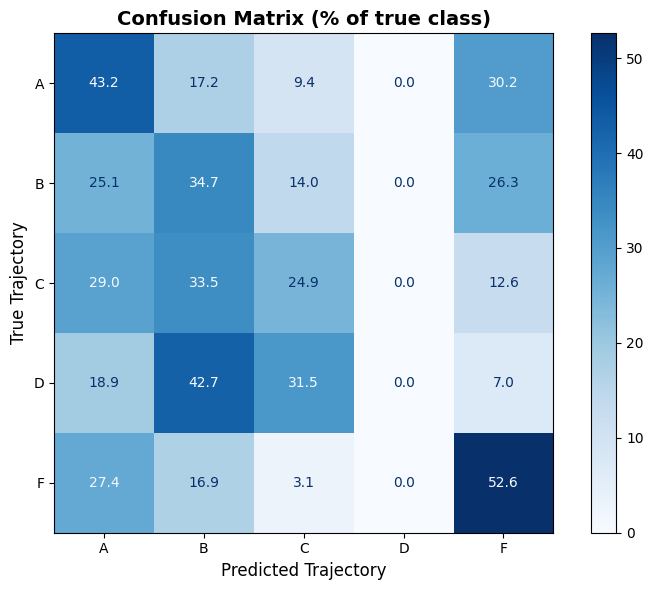


--- Refitting model on full data for SHAP analysis ---
--- Computing SHAP values (this may take a few minutes) ---
  Using 10,000 samples for SHAP (subsampled from 89,872)
Final: 5 classes, each shape (10000, 49)
SHAP values computed successfully!


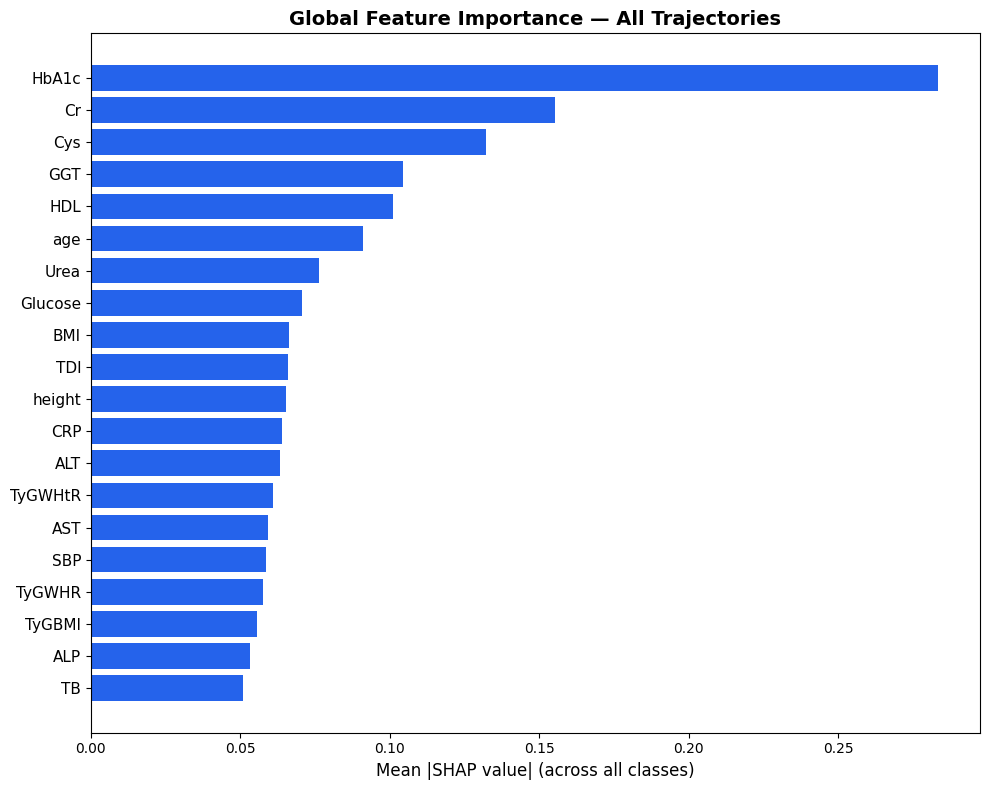


--- SHAP Summary for Trajectory A ---


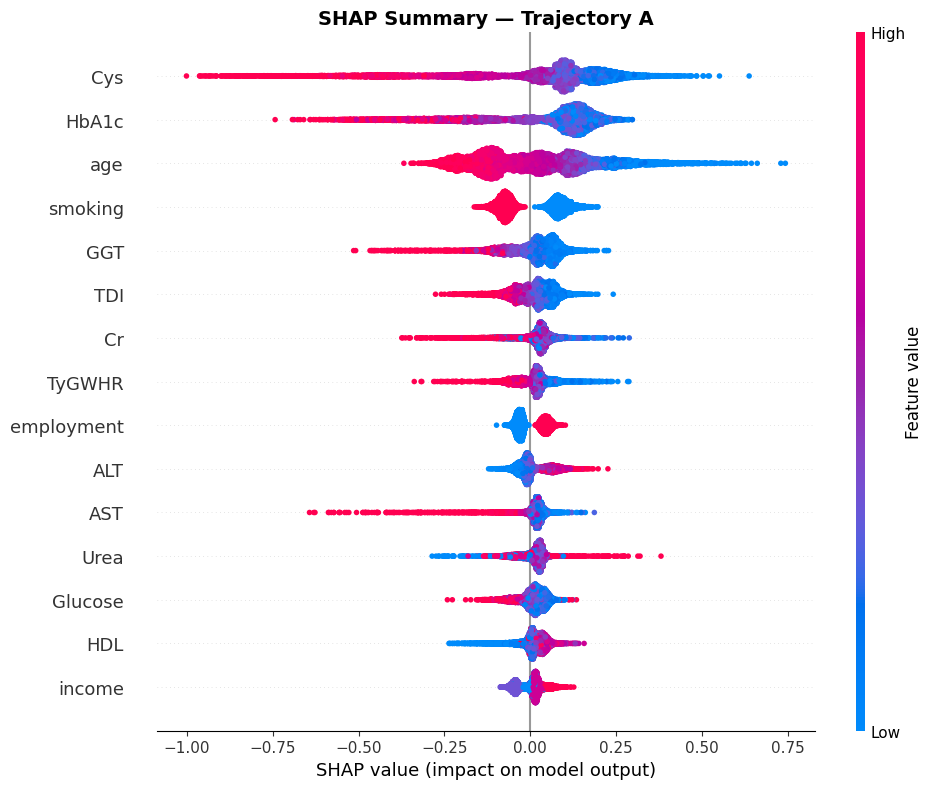


--- SHAP Summary for Trajectory B ---


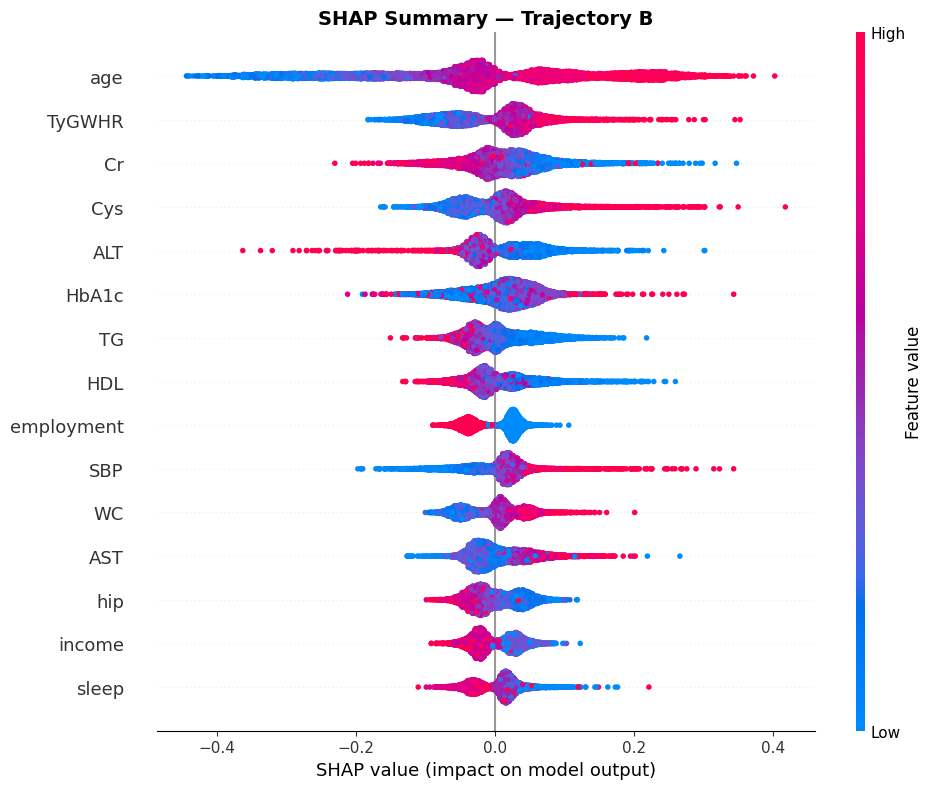


--- SHAP Summary for Trajectory C ---


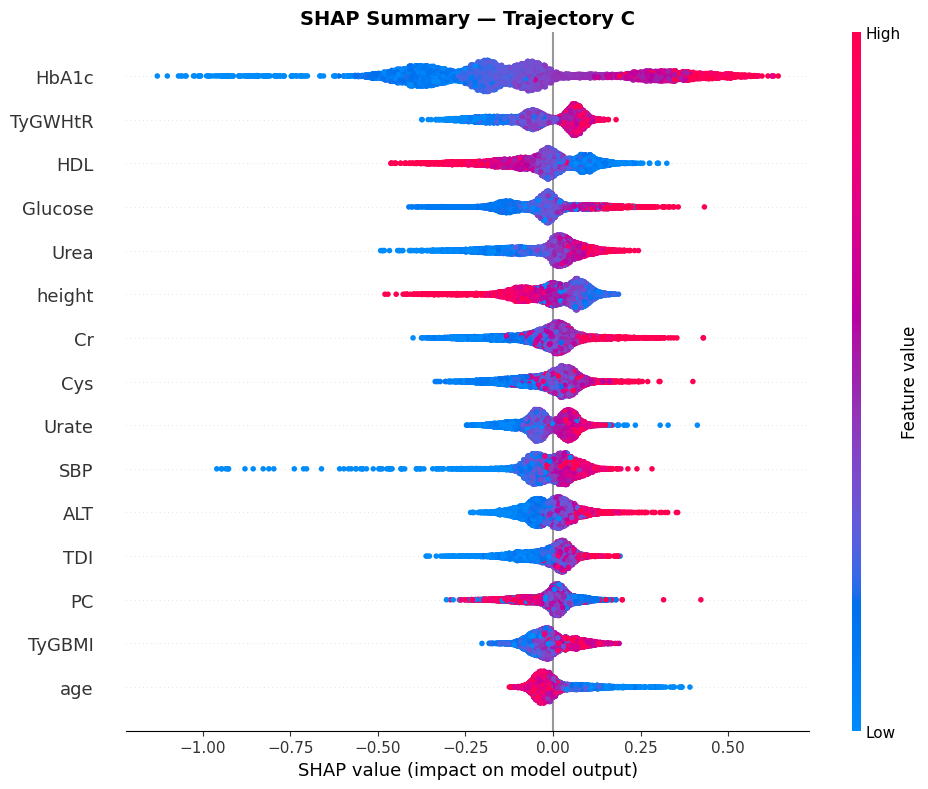


--- SHAP Summary for Trajectory D ---


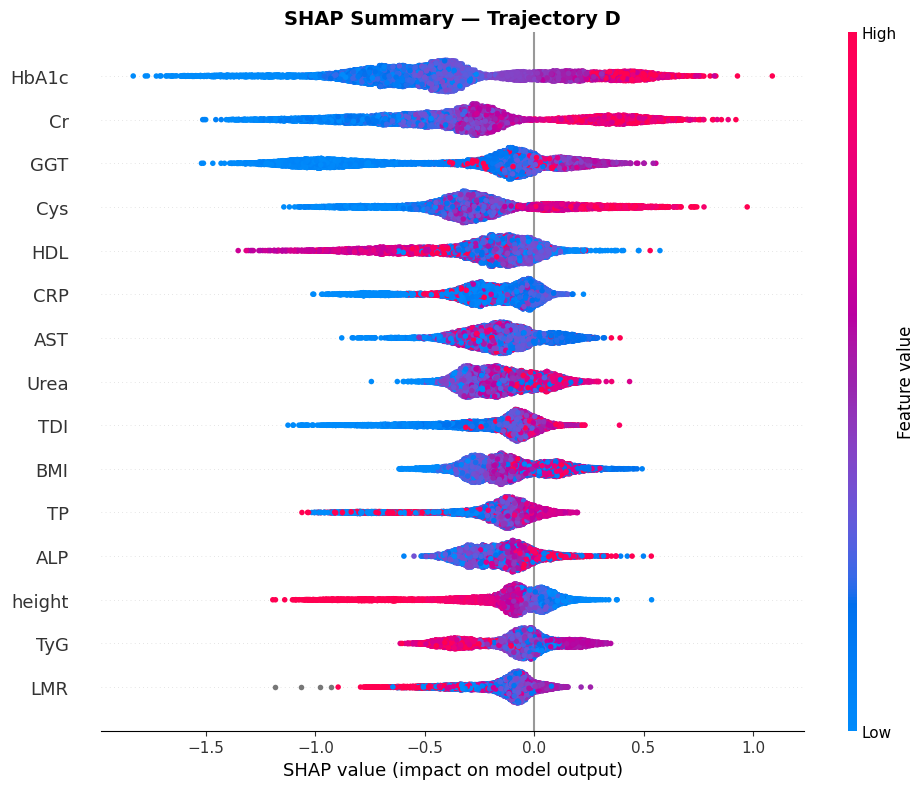


--- SHAP Summary for Trajectory F ---


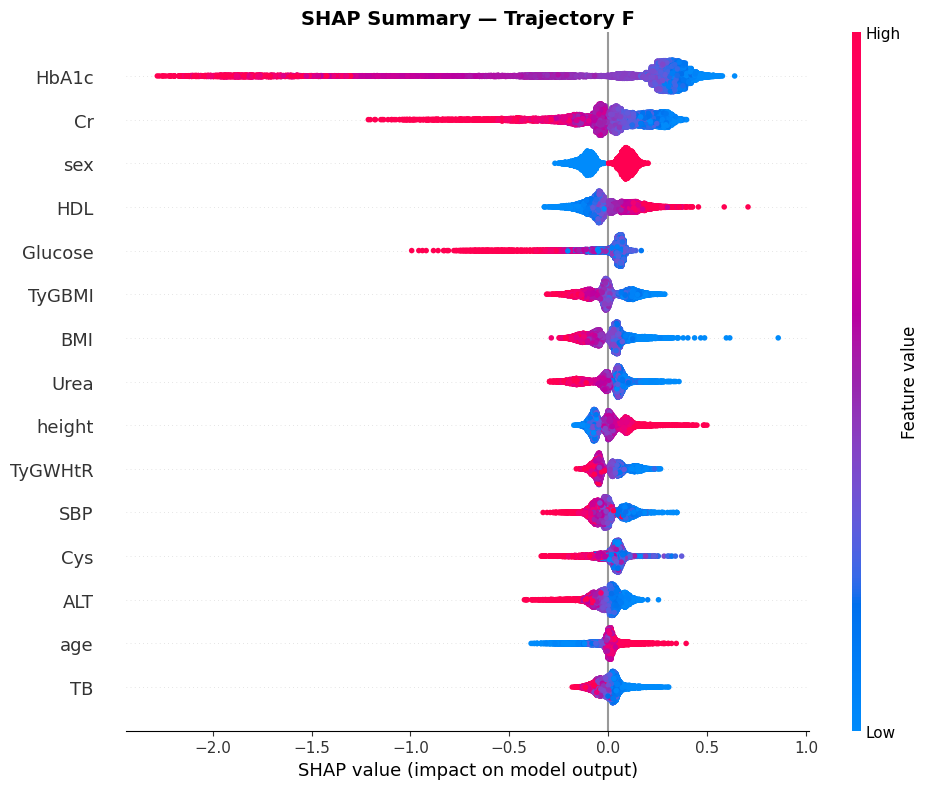


TOP 15 FEATURES PER TRAJECTORY (by mean |SHAP|)

--- Trajectory A ---
   1. Cys                        SHAP=0.1798
   2. HbA1c                      SHAP=0.1526
   3. age                        SHAP=0.1360
   4. smoking                    SHAP=0.0817
   5. GGT                        SHAP=0.0598
   6. TDI                        SHAP=0.0466
   7. Cr                         SHAP=0.0435
   8. TyGWHR                     SHAP=0.0382
   9. employment                 SHAP=0.0381
  10. ALT                        SHAP=0.0319
  11. AST                        SHAP=0.0311
  12. Urea                       SHAP=0.0301
  13. Glucose                    SHAP=0.0294
  14. HDL                        SHAP=0.0292
  15. income                     SHAP=0.0285

--- Trajectory B ---
   1. age                        SHAP=0.1271
   2. TyGWHR                     SHAP=0.0521
   3. Cr                         SHAP=0.0430
   4. Cys                        SHAP=0.0418
   5. ALT                        SHAP=0.0400
   6. H

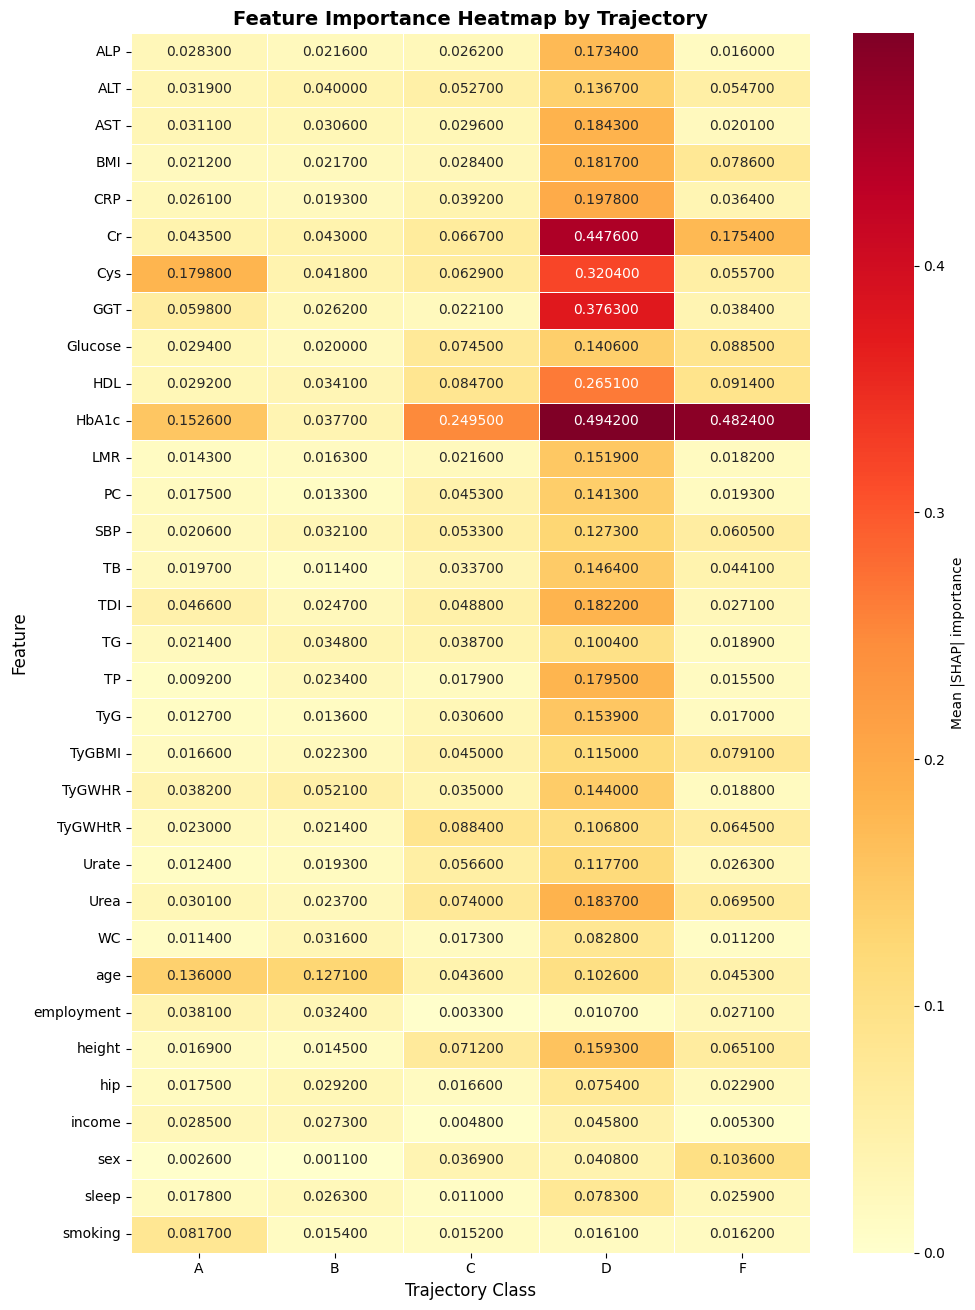

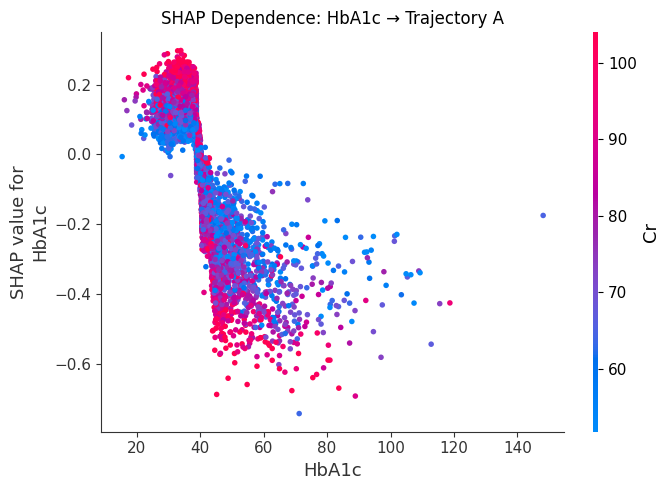

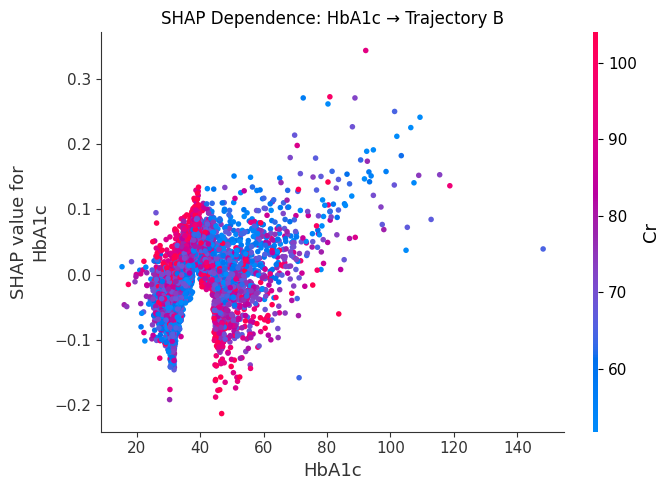

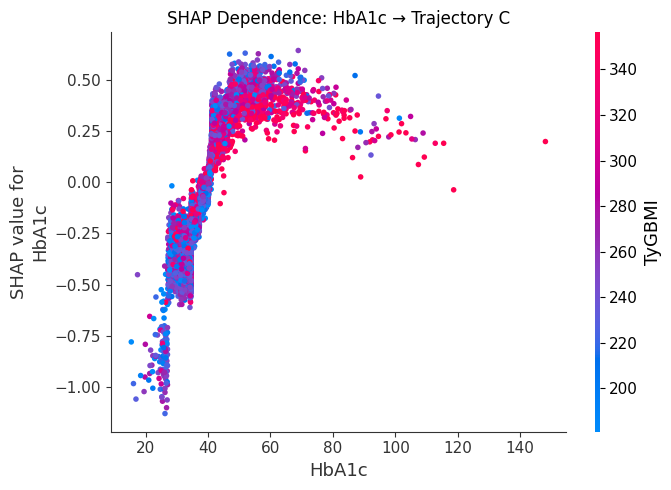

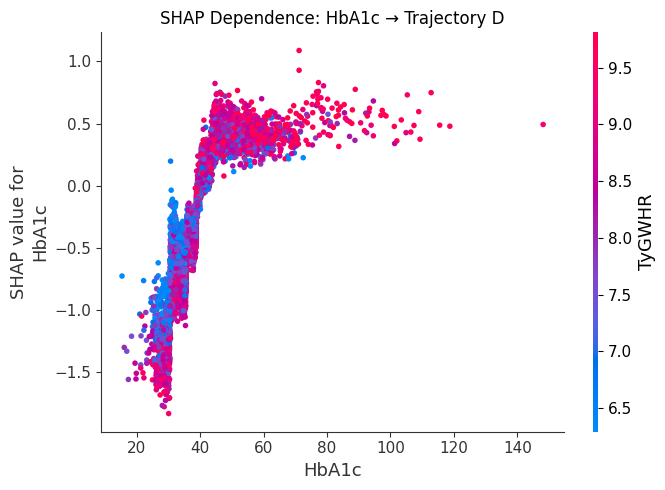

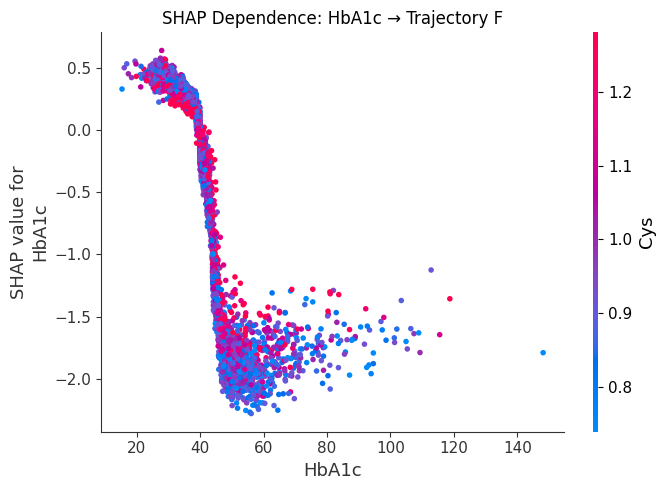

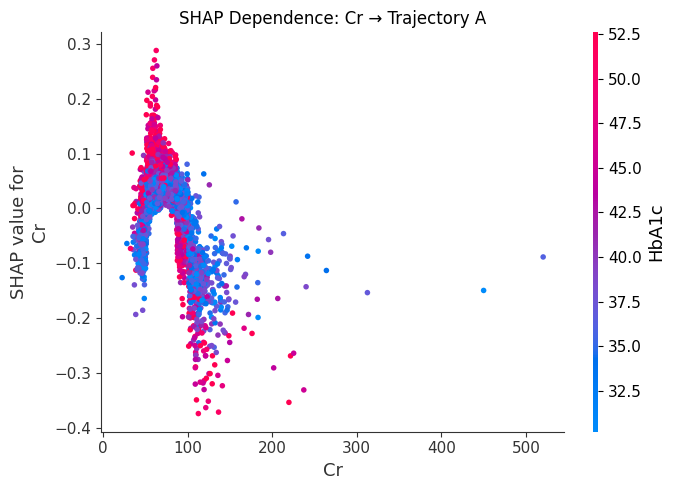

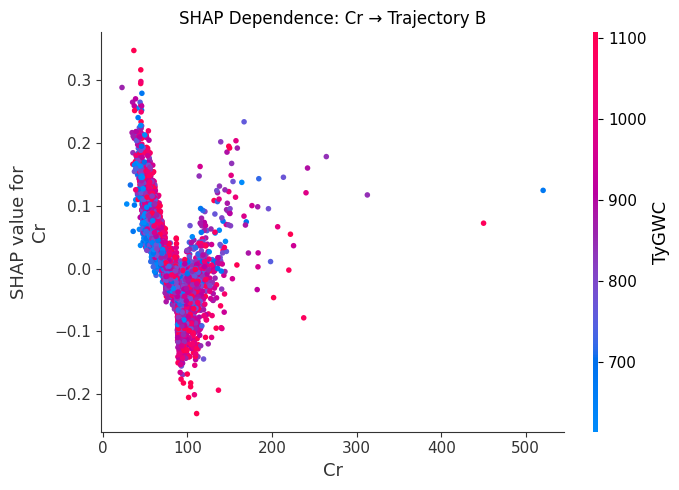

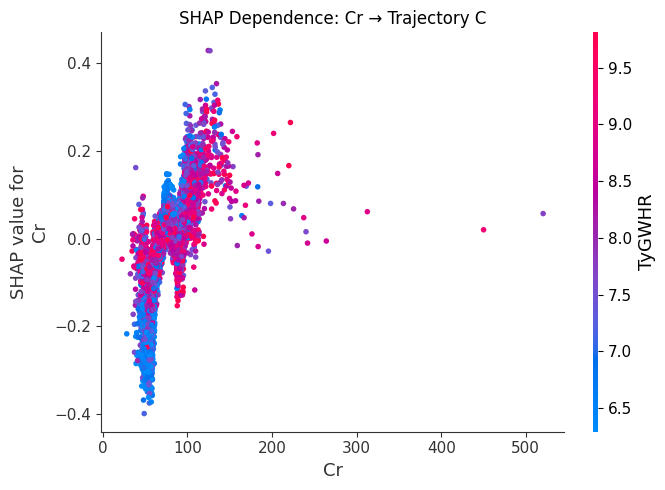

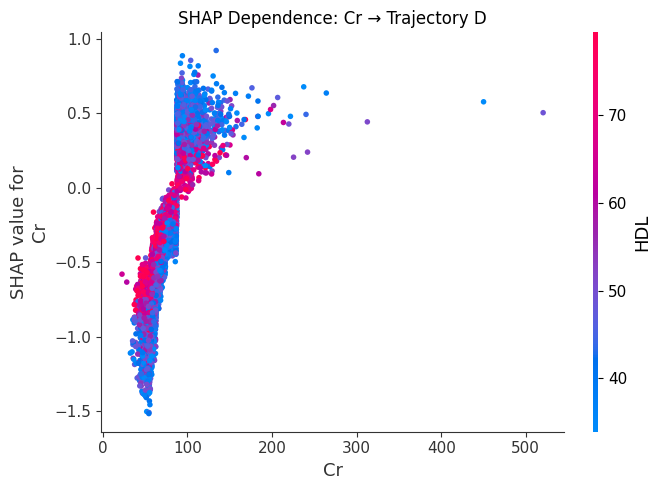

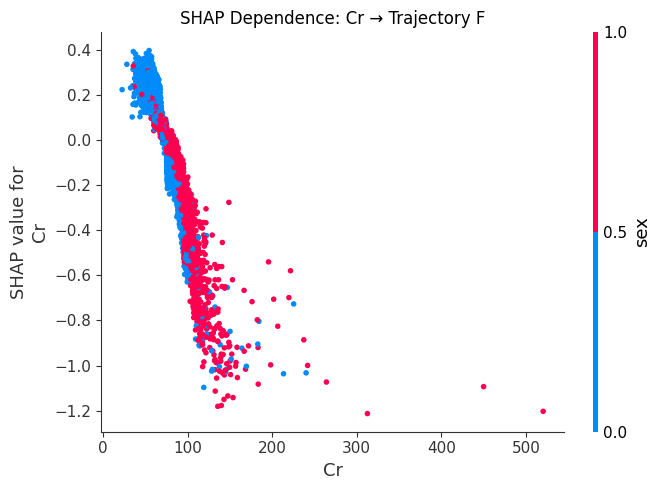

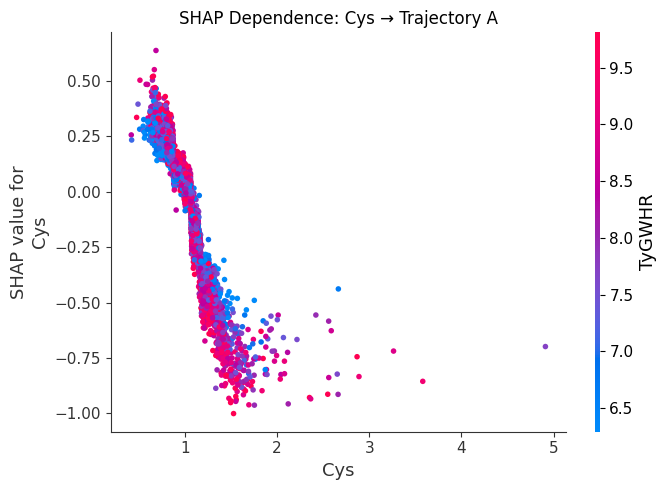

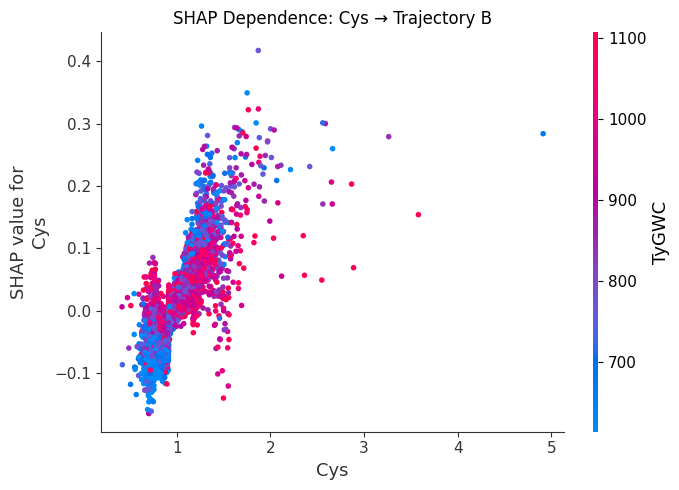

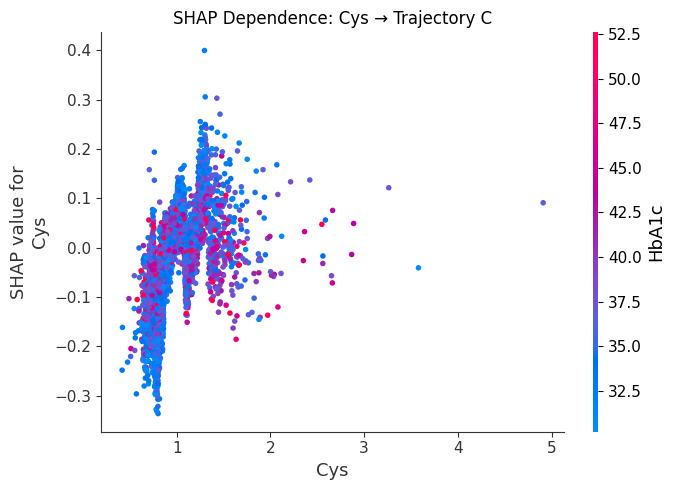

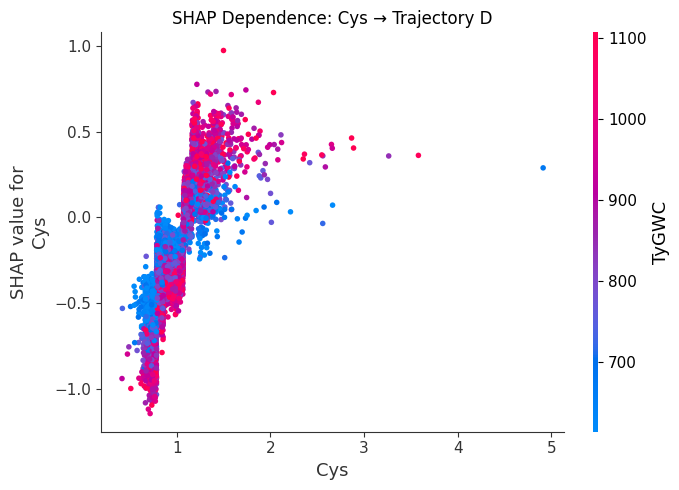

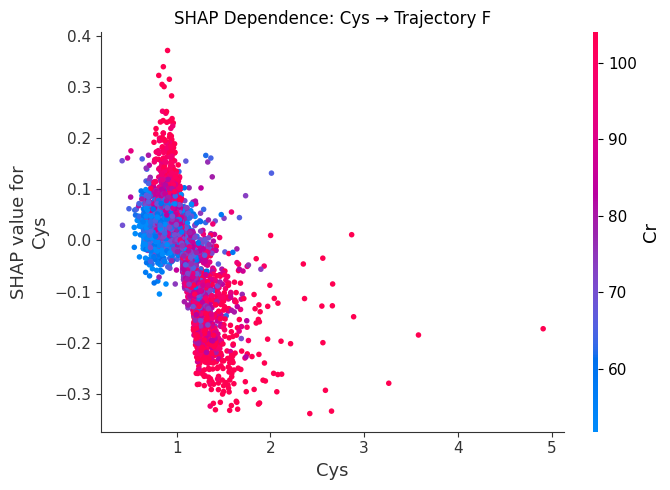


✅ Pipeline complete! All figures saved.
Key outputs:
  - confusion_matrix.png
  - shap_global_importance.png
  - shap_summary_trajectory_<X>.png  (per class)
  - shap_heatmap_by_trajectory.png
  - shap_dep_<feature>_traj_<class>.png  (top 3 features × classes)


In [17]:
# ============================================================
# CELL: Full ML Pipeline — Risk Factor Analysis per Trajectory
# ============================================================
# Paste this cell AFTER your preprocessing cell in the notebook.
# Requirements: pip install xgboost shap scikit-learn matplotlib seaborn
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)
import xgboost as xgb
import shap

# ------------------------------------------------------------------
# 1) FEATURE / TARGET SETUP
# ------------------------------------------------------------------

# Target
target_col = "trajectory"

# Drop "None" trajectory if you only care about disease trajectories.
# SET THIS TO True to KEEP "None" as a class, False to EXCLUDE it.
KEEP_NONE_CLASS = False

if not KEEP_NONE_CLASS:
    df_ml = df[df[target_col] != "None"].copy()
    print(f"Dropped 'None' class. Remaining rows: {len(df_ml):,}")
else:
    df_ml = df.copy()
    print(f"Keeping all classes. Total rows: {len(df_ml):,}")

# --- Define feature columns ---
# Continuous risk factors
continuous_features = [
    "SII", "NLR", "PLR", "LMR", "CRP",
    "WBC", "NC", "MC", "LC", "PC",
    "ALT", "ALP", "AST", "GGT", "TB", "TP", "Alb",
    "Cys", "Cr", "Urate", "Urea",
    "TG", "Glucose", "BMI", "WC", "height", "HDL",
    "age", "TDI",
    "SBP", "DBP", "HbA1c",
    "TyG", "TyGBMI", "TyGWC", "TyGWHtR", "TG_HDL_ratio", "TyGWHR",
    "sleep", "hip",
]

# Categorical risk factors (will be label-encoded)
categorical_features = [
    "sex", "ethnic", "education", "employment", "income",
    "smoking", "drinking", "Regular_physical_activity", "Healthy_diet",
]

# Keep only columns that actually exist in your dataframe
continuous_features = [c for c in continuous_features if c in df_ml.columns]
categorical_features = [c for c in categorical_features if c in df_ml.columns]
all_features = continuous_features + categorical_features

print(f"Continuous features: {len(continuous_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features: {len(all_features)}")

# ------------------------------------------------------------------
# 2) PREPROCESSING
# ------------------------------------------------------------------

X = df_ml[all_features].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y_raw = df_ml[target_col].copy()

# Encode categoricals as integers (XGBoost handles them natively)
label_encoders = {}
for col in categorical_features:
    X[col] = X[col].astype(str)  # handle mixed types
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)
class_names = le_target.classes_
n_classes = len(class_names)

print(f"\nTarget classes: {list(class_names)}")
print(f"Class distribution:\n{pd.Series(y_raw).value_counts().to_string()}")

# ------------------------------------------------------------------
# 3) CLASS WEIGHTS (handle imbalance)
# ------------------------------------------------------------------
class_counts = np.bincount(y)
total = len(y)
# Balanced weights: inversely proportional to class frequency
sample_weights_map = {i: total / (n_classes * c) for i, c in enumerate(class_counts)}
sample_weights = np.array([sample_weights_map[yi] for yi in y])

print(f"\nClass weights (balanced):")
for i, name in enumerate(class_names):
    print(f"  {name}: {sample_weights_map[i]:.2f}")

# ------------------------------------------------------------------
# 4) XGBOOST MODEL + STRATIFIED CV
# ------------------------------------------------------------------
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    early_stopping_rounds=None,  # not used in CV predict
    tree_method="hist",          # fast for large datasets
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Running 5-fold stratified cross-validation ---")
try:
    # scikit-learn >= 1.4
    y_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        params={"sample_weight": sample_weights},
    )
except TypeError:
    # scikit-learn < 1.4
    y_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        fit_params={"sample_weight": sample_weights},
    )
y_pred = np.argmax(y_pred_proba, axis=1)

# ------------------------------------------------------------------
# 5) EVALUATION METRICS
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (5-fold CV)")
print("=" * 60)
print(classification_report(y, y_pred, target_names=class_names, digits=3))

# Multi-class AUC (one-vs-rest)
try:
    auc_ovr = roc_auc_score(y, y_pred_proba, multi_class="ovr", average="weighted")
    print(f"Weighted One-vs-Rest AUC: {auc_ovr:.4f}")

    # Per-class AUC
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y, classes=list(range(n_classes)))
    print("\nPer-class AUC (OvR):")
    for i, name in enumerate(class_names):
        try:
            auc_i = roc_auc_score(y_bin[:, i], y_pred_proba[:, i])
            print(f"  {name}: {auc_i:.4f}")
        except ValueError:
            print(f"  {name}: N/A (too few samples)")
except Exception as e:
    print(f"AUC calculation note: {e}")

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pct,
    display_labels=class_names
)
disp.plot(ax=ax, cmap="Blues", values_format=".1f")
ax.set_title("Confusion Matrix (% of true class)", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Trajectory", fontsize=12)
ax.set_ylabel("True Trajectory", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 6) REFIT ON FULL DATA FOR SHAP
# ------------------------------------------------------------------
print("\n--- Refitting model on full data for SHAP analysis ---")
model_full = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    tree_method="hist",
)
model_full.fit(X, y, sample_weight=sample_weights)

# ------------------------------------------------------------------
# 7) SHAP ANALYSIS
# ------------------------------------------------------------------
print("--- Computing SHAP values (this may take a few minutes) ---")

explainer = shap.TreeExplainer(model_full)

# For very large datasets, use a subsample for SHAP
MAX_SHAP_SAMPLES = 10000
if len(X) > MAX_SHAP_SAMPLES:
    np.random.seed(42)
    shap_idx = np.random.choice(len(X), MAX_SHAP_SAMPLES, replace=False)
    X_shap = X.iloc[shap_idx]
    print(f"  Using {MAX_SHAP_SAMPLES:,} samples for SHAP (subsampled from {len(X):,})")
else:
    X_shap = X
    shap_idx = np.arange(len(X))

shap_values = explainer.shap_values(X_shap)
# shap_values shape: (n_classes, n_samples, n_features) or list of arrays

# Normalize shap_values to list of (n_samples, n_features), one per class
if isinstance(shap_values, np.ndarray):
    if shap_values.ndim == 3:
        # Could be (n_classes, n_samples, n_features) or (n_samples, n_features, n_classes)
        if shap_values.shape[0] == n_classes:
            shap_values = [shap_values[i] for i in range(n_classes)]
        elif shap_values.shape[2] == n_classes:
            shap_values = [shap_values[:, :, i] for i in range(n_classes)]
        elif shap_values.shape[0] == len(X_shap):
            # (n_samples, n_features, n_classes)
            shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif shap_values.ndim == 2:
        # Single output — wrap in list
        shap_values = [shap_values]
elif isinstance(shap_values, list):
    # Already a list — verify inner shapes
    if shap_values[0].ndim == 1:
        # Flat — something unusual, reshape
        shap_values = [sv.reshape(len(X_shap), -1) for sv in shap_values]

print(f"Final: {len(shap_values)} classes, each shape {shap_values[0].shape}")
assert shap_values[0].shape == (len(X_shap), len(all_features)), \
    f"Shape mismatch: got {shap_values[0].shape}, expected ({len(X_shap)}, {len(all_features)})"

print("SHAP values computed successfully!")

# ------------------------------------------------------------------
# 8) SHAP VISUALIZATIONS
# ------------------------------------------------------------------

# --- 8a) Global feature importance (mean |SHAP| across all classes) ---
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (n_samples, n_features)
global_importance = pd.DataFrame({
    "feature": all_features,
    "mean_abs_shap": mean_abs_shap.mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(all_features))
top_global = global_importance.head(top_n)
ax.barh(range(top_n), top_global["mean_abs_shap"].values[::-1], color="#2563EB")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_global["feature"].values[::-1], fontsize=11)
ax.set_xlabel("Mean |SHAP value| (across all classes)", fontsize=12)
ax.set_title("Global Feature Importance — All Trajectories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 8b) Per-class SHAP summary (beeswarm) ---
for i, name in enumerate(class_names):
    print(f"\n--- SHAP Summary for Trajectory {name} ---")
    fig = plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values[i], X_shap,
        feature_names=all_features,
        max_display=15,
        show=False,
        plot_size=None,
    )
    plt.title(f"SHAP Summary — Trajectory {name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"shap_summary_trajectory_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# --- 8c) Per-class feature ranking table ---
print("\n" + "=" * 60)
print("TOP 15 FEATURES PER TRAJECTORY (by mean |SHAP|)")
print("=" * 60)

ranking_dict = {}
for i, name in enumerate(class_names):
    imp = pd.Series(np.abs(shap_values[i]).mean(axis=0), index=all_features)
    imp = imp.sort_values(ascending=False)
    ranking_dict[name] = imp
    print(f"\n--- Trajectory {name} ---")
    for rank, (feat, val) in enumerate(imp.head(15).items(), 1):
        print(f"  {rank:2d}. {feat:<25s}  SHAP={val:.4f}")

# --- 8d) Heatmap: top features × trajectory classes ---
top_k = 15
all_top_features = set()
for name in class_names:
    all_top_features.update(ranking_dict[name].head(top_k).index)
all_top_features = sorted(all_top_features)

heatmap_data = pd.DataFrame(
    {name: ranking_dict[name].reindex(all_top_features) for name in class_names}
)
# Use a shared color scale so darker cells reflect larger absolute importance values
heatmap_max = np.nanmax(heatmap_data.to_numpy())

fig, ax = plt.subplots(figsize=(10, max(8, len(all_top_features) * 0.4)))
sns.heatmap(
    heatmap_data, annot=heatmap_data.round(4), fmt=".6f",
    vmin=0, vmax=heatmap_max,
    cmap="YlOrRd", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean |SHAP| importance"}
)
ax.set_title("Feature Importance Heatmap by Trajectory", fontsize=14, fontweight="bold")
ax.set_xlabel("Trajectory Class", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("shap_heatmap_by_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 8e) SHAP dependence plot for top 3 global features ---
top3 = global_importance["feature"].head(3).tolist()
for feat in top3:
    feat_idx = all_features.index(feat)
    for i, name in enumerate(class_names):
        fig, ax = plt.subplots(figsize=(7, 5))
        shap.dependence_plot(
            feat_idx, shap_values[i], X_shap,
            feature_names=all_features,
            ax=ax, show=False,
        )
        ax.set_title(f"SHAP Dependence: {feat} → Trajectory {name}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"shap_dep_{feat}_traj_{name}.png", dpi=150, bbox_inches="tight")
        plt.show()

print("\n✅ Pipeline complete! All figures saved.")
print("Key outputs:")
print("  - confusion_matrix.png")
print("  - shap_global_importance.png")
print("  - shap_summary_trajectory_<X>.png  (per class)")
print("  - shap_heatmap_by_trajectory.png")
print("  - shap_dep_<feature>_traj_<class>.png  (top 3 features × classes)")

# New result

In [4]:
# -------------------------------------------------
# FIX DEATH HANDLING BEFORE ANY NEW ANALYSIS
# -------------------------------------------------
# Choose the right death date column if you have one
possible_death_date_cols = ["date_death", "death_date", "death_dt"]

death_date_col = None
for c in possible_death_date_cols:
    if c in df.columns:
        death_date_col = c
        break

if death_date_col is not None:
    df["death_date"] = pd.to_datetime(df[death_date_col], errors="coerce")
    df["death_flag"] = df["death_date"].notna().astype(int)
else:
    # fallback: assume death is binary 0/1
    df["death_flag"] = pd.to_numeric(df["death"], errors="coerce").fillna(0).astype(int)
    df["death_date"] = pd.NaT

# ============================================================
# CELL 0: EXTRA IMPORTS
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb

# ============================================================
# CELL 1: FEATURE GROUPS + ANALYSIS DATASET
# ============================================================
target_col = "trajectory"
KEEP_NONE_CLASS = False

if not KEEP_NONE_CLASS:
    df_analysis = df[df[target_col] != "None"].copy()
else:
    df_analysis = df.copy()

# -------------------------
# Feature groups
# -------------------------
clinical_core = [
    "age", "sex", "BMI", "WC", "SBP", "DBP", "Glucose", "HbA1c",
    "Cr", "Cys", "Urate", "TDI"
]

tyg_related = [
    "TyG", "TyGBMI", "TyGWC", "TyGWHtR", "TyGWHR", "TG_HDL_ratio", "TG", "HDL"
]

liver_markers = [
    "ALT", "ALP", "AST", "GGT", "TB", "TP", "Alb"
]

inflammation_markers = [
    "SII", "NLR", "PLR", "LMR", "CRP", "WBC", "NC", "MC", "LC", "PC"
]

renal_markers = [
    "Urea"
]

social_behavioral = [
    "ethnic", "education", "employment", "income",
    "smoking", "drinking", "Regular_physical_activity",
    "Healthy_diet", "sleep"
]

other_features = [
    "height", "hip"
]

feature_groups = {
    "clinical_core": clinical_core,
    "tyg_related": tyg_related,
    "liver_markers": liver_markers,
    "inflammation_markers": inflammation_markers,
    "renal_markers": renal_markers,
    "social_behavioral": social_behavioral,
    "other_features": other_features,
}

# Keep only columns that exist
for k in feature_groups:
    feature_groups[k] = [c for c in feature_groups[k] if c in df_analysis.columns]

all_features = []
for k in feature_groups:
    all_features.extend(feature_groups[k])
all_features = list(dict.fromkeys(all_features))

categorical_features = [c for c in all_features if df_analysis[c].dtype == "object" or c in [
    "sex", "ethnic", "education", "employment", "income",
    "smoking", "drinking", "Regular_physical_activity", "Healthy_diet"
]]
categorical_features = [c for c in categorical_features if c in all_features]
continuous_features = [c for c in all_features if c not in categorical_features]

print("Rows:", len(df_analysis))
print("Total features:", len(all_features))
print("Continuous:", len(continuous_features))
print("Categorical:", len(categorical_features))
print("Classes:\n", df_analysis[target_col].value_counts())

# ============================================================
# CELL 2: PREPARE X, y, WEIGHTS
# ============================================================
X_raw = df_analysis[all_features].copy()
y_raw = df_analysis[target_col].copy()

# ============================================================
# CLEAN X_raw
# ============================================================
X_raw = X_raw.copy()

# Replace inf with NaN first
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# For numeric columns, coerce impossible strings to NaN
for c in X_raw.columns:
    if c not in categorical_features:
        X_raw[c] = pd.to_numeric(X_raw[c], errors="coerce")

# Optional: cap extremely huge values to NaN
HUGE_THRESHOLD = 1e10
for c in X_raw.columns:
    if c not in categorical_features:
        s = X_raw[c]
        X_raw.loc[s.abs() > HUGE_THRESHOLD, c] = np.nan

# encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)
class_names = le_target.classes_
n_classes = len(class_names)

# sample weights for imbalance
class_counts = np.bincount(y)
total = len(y)
sample_weights_map = {i: total / (n_classes * c) for i, c in enumerate(class_counts)}
sample_weights = np.array([sample_weights_map[yi] for yi in y])

print("Classes:", list(class_names))
print("Class weights:", {class_names[i]: round(sample_weights_map[i], 3) for i in range(n_classes)})

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder

# ------------------------------------------------------------
# helper to clean numeric columns
# ------------------------------------------------------------
def clean_numeric_df(X):
    X = pd.DataFrame(X).copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
        X.loc[X[c].abs() > 1e10, c] = np.nan
    return X

# ------------------------------------------------------------
# XGBoost preprocessor
# ------------------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("cleaner", FunctionTransformer(clean_numeric_df)),
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor_for_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, continuous_features),
        ("cat", categorical_transformer_xgb, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Logistic regression preprocessor
# ------------------------------------------------------------
categorical_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_for_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("cleaner", FunctionTransformer(clean_numeric_df)),
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), continuous_features),
        ("cat", categorical_transformer_linear, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

Rows: 89872
Total features: 49
Continuous: 40
Categorical: 9
Classes:
 trajectory
A    48246
B    19661
F    17979
C     3843
D      143
Name: count, dtype: int64
Classes: ['A', 'B', 'C', 'D', 'F']
Class weights: {'A': np.float64(0.373), 'B': np.float64(0.914), 'C': np.float64(4.677), 'D': np.float64(125.695), 'F': np.float64(1.0)}


XGBoost: fold 1 done
XGBoost: fold 2 done
XGBoost: fold 3 done
XGBoost: fold 4 done
XGBoost: fold 5 done
Multinomial_Logistic: fold 1 done
Multinomial_Logistic: fold 2 done
Multinomial_Logistic: fold 3 done
Multinomial_Logistic: fold 4 done
Multinomial_Logistic: fold 5 done
OVERALL METRICS


,model,macro_f1,weighted_f1,macro_precision,weighted_precision,macro_recall,weighted_recall,macro_auroc_ovr,weighted_auroc_ovr,macro_prauc_ovr,weighted_prauc_ovr
0,XGBoost,0.2837,0.4406,0.2867,0.4964,0.3121,0.4228,0.6743,0.6572,0.2877,0.4966
1,Multinomial_Logistic,0.2403,0.3680,0.2777,0.4919,0.3326,0.3324,0.6628,0.6336,0.2723,0.4766



CLASS-SPECIFIC ONE-vs-REST METRICS


,model,class,support,auroc_ovr,prauc_ovr,f1_ovr,precision_ovr,recall_ovr
0,XGBoost,A,48246,0.6393,0.6500,0.5187,0.6549,0.4294
1,XGBoost,B,19661,0.6602,0.3459,0.3494,0.3508,0.3481
2,XGBoost,C,3843,0.7040,0.0992,0.1553,0.1111,0.2576
3,XGBoost,D,143,0.6765,0.0047,0.0000,0.0000,0.0000
4,XGBoost,F,17979,0.6916,0.3387,0.3951,0.3167,0.5251
5,Multinomial_Logistic,A,48246,0.6194,0.6330,0.4317,0.6609,0.3206
6,Multinomial_Logistic,B,19661,0.6137,0.3098,0.2420,0.3310,0.1907
7,Multinomial_Logistic,C,3843,0.6929,0.0868,0.1318,0.0882,0.2607
8,Multinomial_Logistic,D,143,0.7081,0.0060,0.0082,0.0042,0.3566
9,Multinomial_Logistic,F,17979,0.6801,0.3261,0.3879,0.3045,0.5343


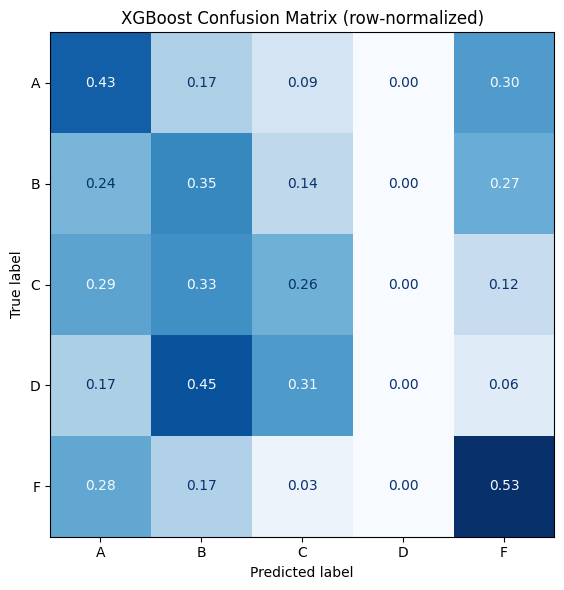

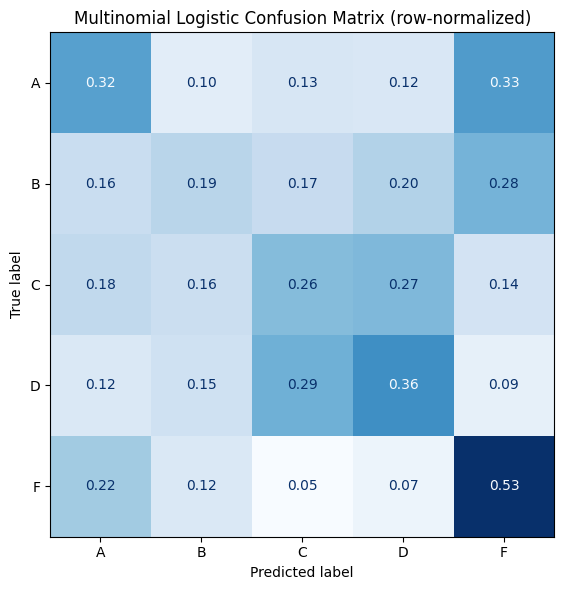

,model,class,support,auroc_ovr,prauc_ovr,f1_ovr,precision_ovr,recall_ovr
6,Multinomial_Logistic,B,19661,0.6137,0.3098,0.2420,0.3310,0.1907
1,XGBoost,B,19661,0.6602,0.3459,0.3494,0.3508,0.3481
7,Multinomial_Logistic,C,3843,0.6929,0.0868,0.1318,0.0882,0.2607
2,XGBoost,C,3843,0.7040,0.0992,0.1553,0.1111,0.2576
8,Multinomial_Logistic,D,143,0.7081,0.0060,0.0082,0.0042,0.3566
3,XGBoost,D,143,0.6765,0.0047,0.0000,0.0000,0.0000
9,Multinomial_Logistic,F,17979,0.6801,0.3261,0.3879,0.3045,0.5343
4,XGBoost,F,17979,0.6916,0.3387,0.3951,0.3167,0.5251


In [5]:
# ============================================================
# CELL 3: DEFINE MODELS
# ============================================================
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ("prep", preprocessor_for_tree),
    ("model", xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss",
        tree_method="hist",
        enable_categorical=False
    ))
])

logit_model = Pipeline(steps=[
    ("prep", preprocessor_for_linear),
    ("model", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# CELL 4: METRICS UTILITIES
# ============================================================
# ============================================================
# SAFE MANUAL CV EVALUATION FUNCTION
# ============================================================
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix
)

def evaluate_multiclass_model(model, X, y, class_names, cv, sample_weights=None, model_name="model"):
    X = X.copy()

    n = len(y)
    n_classes = len(class_names)
    y_pred_proba = np.zeros((n, n_classes), dtype=float)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y[train_idx]

        model_fold = clone(model)

        # fit with weights if provided
        if sample_weights is not None:
            sw_train = sample_weights[train_idx]
            try:
                model_fold.fit(X_train, y_train, model__sample_weight=sw_train)
            except Exception:
                # fallback without weights if the model/pipeline rejects them
                model_fold.fit(X_train, y_train)
        else:
            model_fold.fit(X_train, y_train)

        proba = model_fold.predict_proba(X_test)
        y_pred_proba[test_idx] = proba

        print(f"{model_name}: fold {fold} done")

    y_pred = np.argmax(y_pred_proba, axis=1)
    y_bin = label_binarize(y, classes=np.arange(n_classes))

    metrics_overall = {
        "model": model_name,
        "macro_f1": f1_score(y, y_pred, average="macro"),
        "weighted_f1": f1_score(y, y_pred, average="weighted"),
        "macro_precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y, y_pred, average="weighted", zero_division=0),
        "macro_recall": recall_score(y, y_pred, average="macro", zero_division=0),
        "weighted_recall": recall_score(y, y_pred, average="weighted", zero_division=0),
        "macro_auroc_ovr": roc_auc_score(y, y_pred_proba, multi_class="ovr", average="macro"),
        "weighted_auroc_ovr": roc_auc_score(y, y_pred_proba, multi_class="ovr", average="weighted"),
        "macro_prauc_ovr": average_precision_score(y_bin, y_pred_proba, average="macro"),
        "weighted_prauc_ovr": average_precision_score(y_bin, y_pred_proba, average="weighted"),
    }

    per_class_rows = []
    for i, cname in enumerate(class_names):
        y_true_i = (y == i).astype(int)
        y_prob_i = y_pred_proba[:, i]
        y_pred_i = (y_pred == i).astype(int)

        per_class_rows.append({
            "model": model_name,
            "class": cname,
            "support": int(y_true_i.sum()),
            "auroc_ovr": roc_auc_score(y_true_i, y_prob_i),
            "prauc_ovr": average_precision_score(y_true_i, y_prob_i),
            "f1_ovr": f1_score(y_true_i, y_pred_i, zero_division=0),
            "precision_ovr": precision_score(y_true_i, y_pred_i, zero_division=0),
            "recall_ovr": recall_score(y_true_i, y_pred_i, zero_division=0),
        })

    cm = confusion_matrix(y, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)

    return {
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "overall_metrics": pd.DataFrame([metrics_overall]),
        "per_class_metrics": pd.DataFrame(per_class_rows),
        "confusion_matrix": cm,
        "confusion_matrix_pct": cm_pct,
    }


# Run both models
xgb_results = evaluate_multiclass_model(
    xgb_model, X_raw, y, class_names, cv, sample_weights=sample_weights, model_name="XGBoost"
)

logit_results = evaluate_multiclass_model(
    logit_model, X_raw, y, class_names, cv, sample_weights=None, model_name="Multinomial_Logistic"
)

overall_compare = pd.concat(
    [xgb_results["overall_metrics"], logit_results["overall_metrics"]],
    ignore_index=True
)
per_class_compare = pd.concat(
    [xgb_results["per_class_metrics"], logit_results["per_class_metrics"]],
    ignore_index=True
)

print("OVERALL METRICS")
display(overall_compare.round(4))

print("\nCLASS-SPECIFIC ONE-vs-REST METRICS")
display(per_class_compare.round(4))

# ============================================================
# CELL 5: CONFUSION MATRICES
# ============================================================
def plot_conf_matrix(cm_pct, class_names, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(xgb_results["confusion_matrix_pct"], class_names, "XGBoost Confusion Matrix (row-normalized)")
plot_conf_matrix(logit_results["confusion_matrix_pct"], class_names, "Multinomial Logistic Confusion Matrix (row-normalized)")

# ============================================================
# CELL 6: HIGHLIGHT KEY TRAJECTORIES
# ============================================================
focus_classes = ["B", "C", "D", "F"]
focus_metrics = per_class_compare[per_class_compare["class"].isin(focus_classes)].copy()
display(focus_metrics.sort_values(["class", "model"]).round(4))

# Score calculation

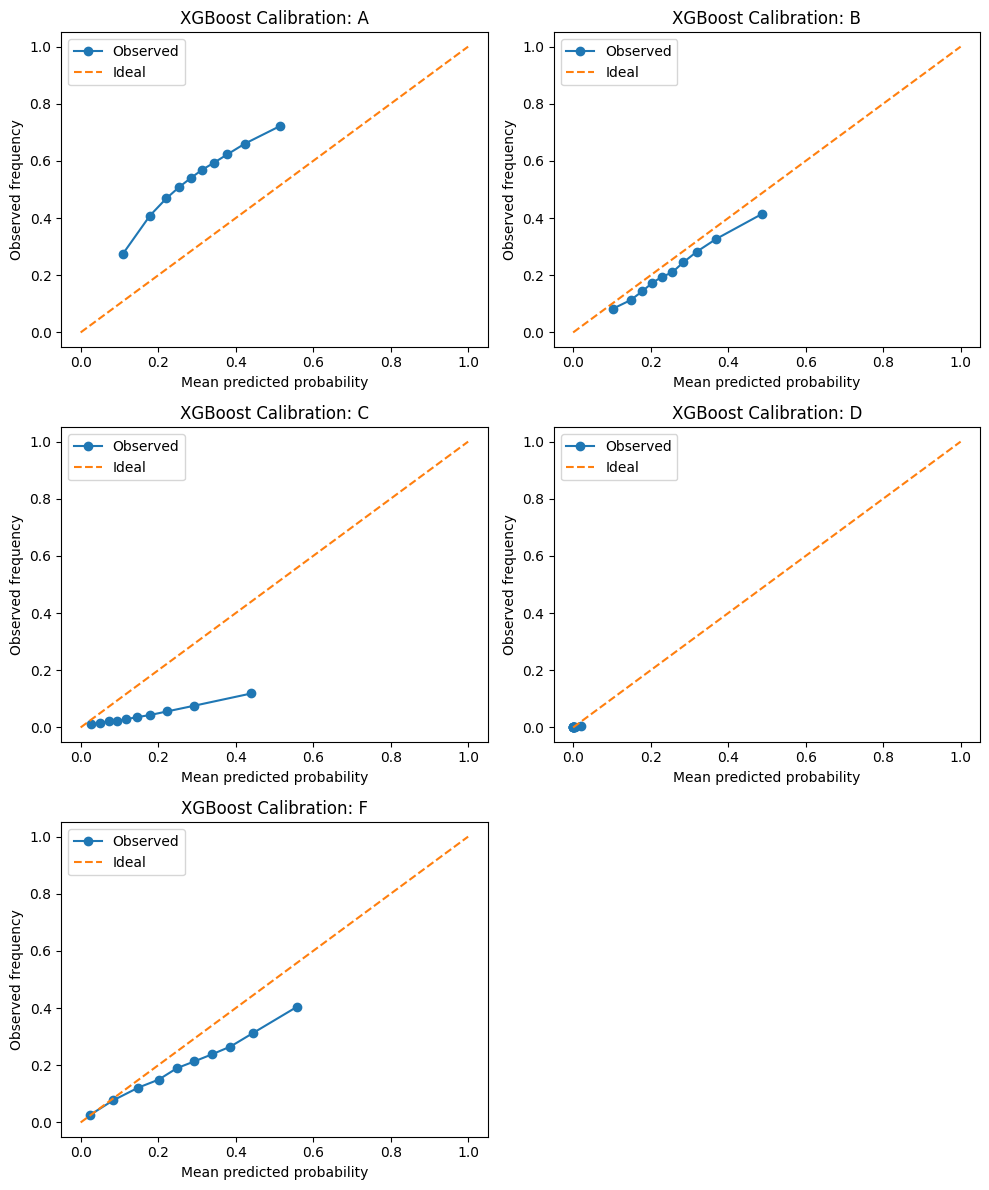

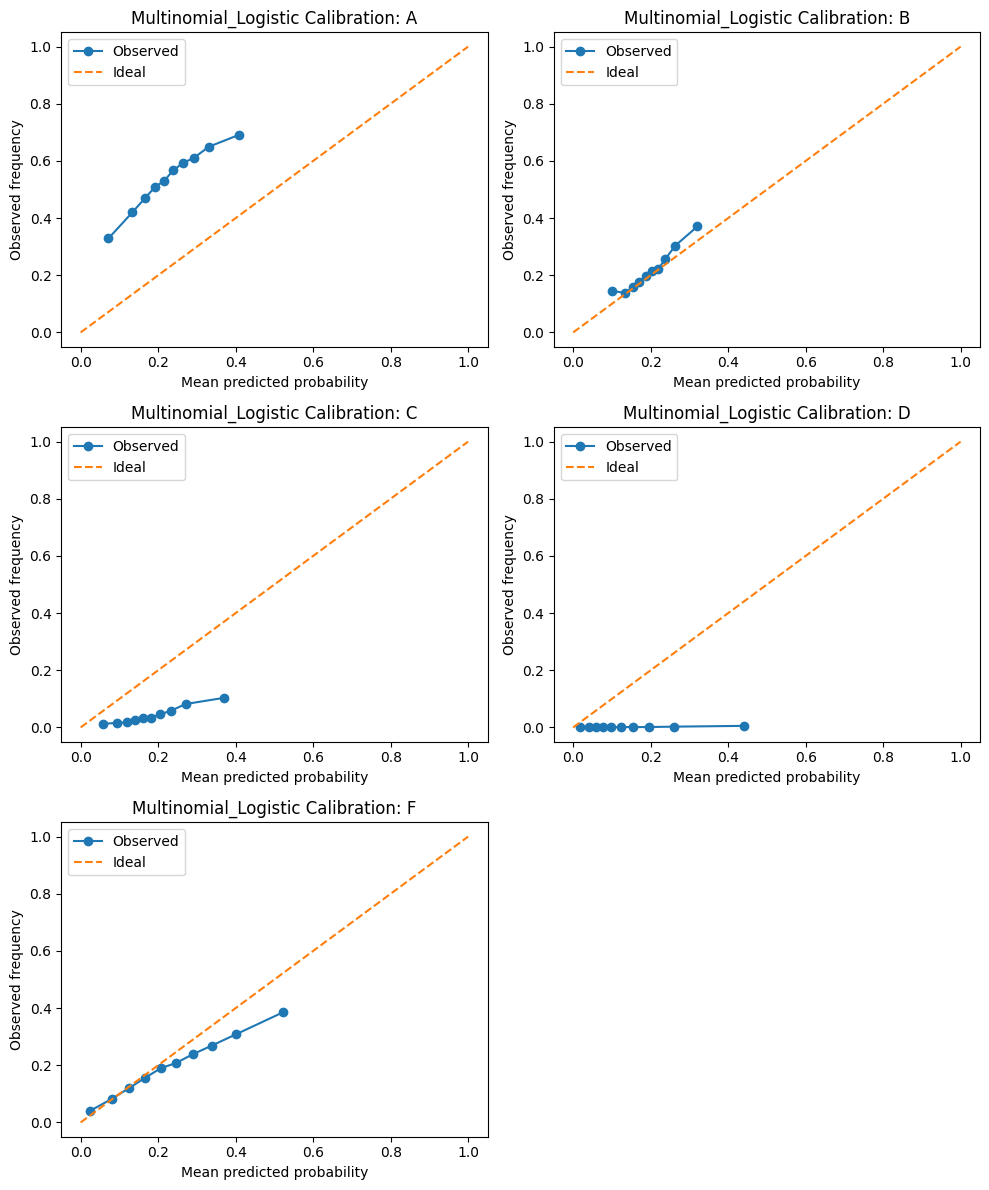

,model,class,brier_score,expected_events,observed_events,E_over_O
0,XGBoost,A,0.2891,27141.0420,48246,0.5626
1,XGBoost,B,0.1630,23177.1286,19661,1.1788
2,XGBoost,C,0.0628,14735.6573,3843,3.8344
3,XGBoost,D,0.0017,287.0877,143,2.0076
4,XGBoost,F,0.1563,24531.0843,17979,1.3644
5,Multinomial_Logistic,A,0.3316,20771.2307,48246,0.4305
6,Multinomial_Logistic,B,0.1666,17884.8232,19661,0.9097
7,Multinomial_Logistic,C,0.0637,16485.6331,3843,4.2898
8,Multinomial_Logistic,D,0.0384,13130.4986,143,91.8217
9,Multinomial_Logistic,F,0.1536,21599.8143,17979,1.2014


,model,multiclass_brier
0,XGBoost,0.6728
1,Multinomial_Logistic,0.7539


Continuous baseline summary


,trajectory,n,mean,sd,median,q25,q75,variable
0,A,48246,59.038635,7.297762,61.00000,54.00000,65.000000,age
1,B,19661,61.664208,6.446379,63.00000,59.00000,67.000000,age
2,C,3843,60.494666,6.936588,62.00000,56.00000,66.000000,age
3,D,143,61.181818,6.446570,63.00000,57.50000,66.000000,age
4,F,17979,60.687636,6.803390,62.00000,57.00000,66.000000,age
5,A,48246,28.829255,5.070982,28.08950,25.37450,31.398075,BMI
6,B,19661,29.689519,5.548851,28.92060,25.88240,32.617200,BMI
7,C,3843,30.676129,5.527560,29.90430,26.88530,33.632750,BMI
8,D,143,30.888797,5.317600,30.04080,27.23800,33.824650,BMI
9,F,17979,27.224731,4.835461,26.62970,24.00790,29.717150,BMI


Categorical baseline summary


,trajectory,variable,level,count,percent
0,A,sex,0,22351,46.327157
1,A,sex,1,25895,53.672843
2,B,sex,0,8100,41.198311
3,B,sex,1,11561,58.801689
4,C,sex,0,1494,38.875878
5,C,sex,1,2349,61.124122
6,D,sex,0,53,37.062937
7,D,sex,1,90,62.937063
8,F,sex,0,8409,46.771233
9,F,sex,1,9570,53.228767


trajectory,A,B,C,D,F
age,"61.00 [54.00, 65.00]","63.00 [59.00, 67.00]","62.00 [56.00, 66.00]","63.00 [57.50, 66.00]","62.00 [57.00, 66.00]"
sex=0 (%),46.327157,41.198311,38.875878,37.062937,46.771233
sex=1 (%),53.672843,58.801689,61.124122,62.937063,53.228767
BMI,"28.09 [25.37, 31.40]","28.92 [25.88, 32.62]","29.90 [26.89, 33.63]","30.04 [27.24, 33.82]","26.63 [24.01, 29.72]"
WC,"95.00 [86.00, 103.00]","98.00 [89.00, 107.00]","100.00 [92.00, 109.00]","100.00 [91.50, 110.50]","91.00 [82.00, 100.00]"
HbA1c,"36.40 [33.70, 39.70]","37.80 [34.70, 42.00]","40.30 [36.10, 47.00]","41.00 [36.75, 46.75]","35.40 [33.10, 37.90]"
Glucose,"90.37 [83.92, 99.16]","92.23 [84.84, 103.85]","95.90 [86.75, 115.61]","94.50 [83.65, 110.49]","89.18 [83.24, 95.85]"
Cr,"73.00 [63.20, 83.40]","75.10 [64.70, 86.90]","76.50 [66.40, 88.50]","87.70 [72.45, 99.80]","70.70 [61.40, 81.40]"
Cys,"0.93 [0.84, 1.03]","0.99 [0.89, 1.11]","0.99 [0.89, 1.11]","1.08 [0.93, 1.22]","0.93 [0.84, 1.03]"
TyGWHtR,"4.96 [4.43, 5.53]","5.18 [4.60, 5.79]","5.41 [4.86, 6.01]","5.35 [4.96, 6.04]","4.71 [4.18, 5.24]"


In [6]:
# ============================================================
# CELL 7: CALIBRATION + BRIER + E/O
# ============================================================
def calibration_summary(y_true, y_pred_proba, class_names, n_bins=10, plot=True, model_name="model"):
    rows = []
    n_classes = len(class_names)

    if plot:
        ncols = 2
        nrows = int(np.ceil(n_classes / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
        axes = np.array(axes).reshape(-1)

    for i, cname in enumerate(class_names):
        y_i = (y_true == i).astype(int)
        p_i = y_pred_proba[:, i]

        # Brier score
        brier = brier_score_loss(y_i, p_i)

        # Expected / observed
        expected = p_i.sum()
        observed = y_i.sum()
        eo_ratio = expected / observed if observed > 0 else np.nan

        frac_pos, mean_pred = calibration_curve(y_i, p_i, n_bins=n_bins, strategy="quantile")

        rows.append({
            "model": model_name,
            "class": cname,
            "brier_score": brier,
            "expected_events": expected,
            "observed_events": observed,
            "E_over_O": eo_ratio
        })

        if plot:
            ax = axes[i]
            ax.plot(mean_pred, frac_pos, marker="o", label="Observed")
            ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
            ax.set_title(f"{model_name} Calibration: {cname}")
            ax.set_xlabel("Mean predicted probability")
            ax.set_ylabel("Observed frequency")
            ax.legend()

    if plot:
        for j in range(i + 1, len(axes)):
            axes[j].axis("off")
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(rows)

xgb_calib = calibration_summary(
    y, xgb_results["y_pred_proba"], class_names, n_bins=10, plot=True, model_name="XGBoost"
)
logit_calib = calibration_summary(
    y, logit_results["y_pred_proba"], class_names, n_bins=10, plot=True, model_name="Multinomial_Logistic"
)

calib_compare = pd.concat([xgb_calib, logit_calib], ignore_index=True)
display(calib_compare.round(4))

# ============================================================
# CELL 8: OVERALL MULTICLASS BRIER
# ============================================================
def multiclass_brier(y_true, y_pred_proba, n_classes):
    y_onehot = label_binarize(y_true, classes=np.arange(n_classes))
    return np.mean(np.sum((y_pred_proba - y_onehot) ** 2, axis=1))

overall_brier = pd.DataFrame({
    "model": ["XGBoost", "Multinomial_Logistic"],
    "multiclass_brier": [
        multiclass_brier(y, xgb_results["y_pred_proba"], n_classes),
        multiclass_brier(y, logit_results["y_pred_proba"], n_classes),
    ]
})
display(overall_brier.round(4))

# ============================================================
# CELL 9: DESCRIPTIVE BASELINE TABLE BY TRAJECTORY
# ============================================================
def summarize_continuous(df_in, group_col, cols):
    rows = []
    for c in cols:
        if c not in df_in.columns:
            continue
        tmp = df_in.groupby(group_col)[c].agg(["count", "mean", "std", "median",
                                              lambda x: x.quantile(0.25),
                                              lambda x: x.quantile(0.75)])
        tmp.columns = ["n", "mean", "sd", "median", "q25", "q75"]
        tmp["variable"] = c
        rows.append(tmp.reset_index())
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def summarize_categorical(df_in, group_col, cols):
    rows = []
    for c in cols:
        if c not in df_in.columns:
            continue
        tab = pd.crosstab(df_in[group_col], df_in[c], normalize="index") * 100
        tab_counts = pd.crosstab(df_in[group_col], df_in[c])
        for grp in tab.index:
            for level in tab.columns:
                rows.append({
                    "trajectory": grp,
                    "variable": c,
                    "level": level,
                    "count": tab_counts.loc[grp, level],
                    "percent": tab.loc[grp, level]
                })
    return pd.DataFrame(rows)

baseline_cont = summarize_continuous(df_analysis, "trajectory", continuous_features)
baseline_cat = summarize_categorical(df_analysis, "trajectory", categorical_features)

print("Continuous baseline summary")
display(baseline_cont.head(50))

print("Categorical baseline summary")
display(baseline_cat.head(50))


# ============================================================
# CELL 10: PUBLICATION-STYLE TABLE 1
# ============================================================
selected_table1_vars = [c for c in [
    "age", "sex", "BMI", "WC", "HbA1c", "Glucose", "Cr", "Cys", "TyGWHtR",
    "CRP", "smoking", "drinking", "Regular_physical_activity"
] if c in df_analysis.columns]

table1_parts = []

for c in selected_table1_vars:
    if c in continuous_features:
        tmp = df_analysis.groupby("trajectory")[c].agg(
            lambda x: f"{x.median():.2f} [{x.quantile(0.25):.2f}, {x.quantile(0.75):.2f}]"
        ).to_frame().T
        tmp.index = [c]
        table1_parts.append(tmp)
    else:
        dist = pd.crosstab(df_analysis["trajectory"], df_analysis[c], normalize="index") * 100
        for lvl in dist.columns:
            row = dist[lvl].to_frame().T
            row.index = [f"{c}={lvl} (%)"]
            table1_parts.append(row)

table1 = pd.concat(table1_parts, axis=0)
display(table1)

# Bootstrap confidence intervals and permutation importance

In [8]:
# ============================================================
# CELL 13: PERMUTATION IMPORTANCE + SAFE FEATURE NAMES
# ============================================================
from sklearn.inspection import permutation_importance

# Fit model on full data
xgb_model.fit(X_raw, y, model__sample_weight=sample_weights)

# transformed design matrix
X_prepped = xgb_model.named_steps["prep"].transform(X_raw)

# SAFE feature names:
# numeric columns stay as themselves
# categorical columns also stay as themselves because we used OrdinalEncoder
feature_names_tree = continuous_features + categorical_features

# final estimator
final_tree_model = xgb_model.named_steps["model"]

perm = permutation_importance(
    final_tree_model,
    X_prepped,
    y,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="f1_weighted"
)

perm_importance = pd.DataFrame({
    "feature": feature_names_tree,
    "perm_mean": perm.importances_mean,
    "perm_sd": perm.importances_std
}).sort_values("perm_mean", ascending=False)

display(perm_importance.head(25).round(4))

,feature,perm_mean,perm_sd
0,age,0.0340,0.0006
6,HbA1c,0.0192,0.0008
8,Cys,0.0166,0.0008
7,Cr,0.0158,0.0007
30,CRP,0.0149,0.0004
23,TB,0.0140,0.0005
3,SBP,0.0138,0.0005
33,MC,0.0131,0.0006
20,ALP,0.0122,0.0004
25,Alb,0.0121,0.0006


Completed 5/30 runs
Completed 10/30 runs
Completed 15/30 runs
Completed 20/30 runs
Completed 25/30 runs
Completed 30/30 runs
Top stable predictors:


,mean_importance,sd_importance,median_rank,top_n_freq
feature,,,,
HbA1c,0.0560,0.0023,1.0,1.0000
Cr,0.0388,0.0038,2.0,1.0000
Cys,0.0332,0.0029,3.0,1.0000
TyGBMI,0.0248,0.0021,5.0,1.0000
TyGWHtR,0.0240,0.0025,6.0,0.9333
employment,0.0224,0.0025,11.0,0.9000
GGT,0.0229,0.0030,8.5,0.8667
TyGWC,0.0217,0.0019,12.0,0.8667
WBC,0.0216,0.0018,10.5,0.8667


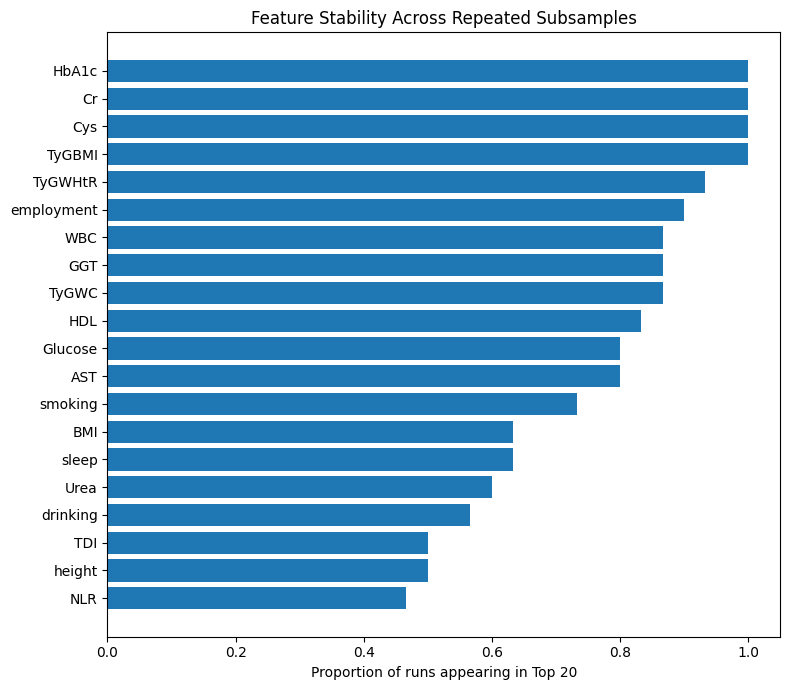

In [ ]:
# ============================================================
# CELL 14: FAST FEATURE STABILITY ANALYSIS
# ============================================================
from sklearn.base import clone

def fast_feature_stability(
    model_pipeline,
    X,
    y,
    feature_names,
    sample_weights=None,
    n_runs=30,          # much faster than 100 bootstrap runs
    sample_frac=0.8,
    top_n=20,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    all_rows = []

    for r in range(n_runs):
        idx = rng.choice(len(X), size=int(len(X) * sample_frac), replace=False)
        Xr = X.iloc[idx].copy()
        yr = y[idx]
        swr = sample_weights[idx] if sample_weights is not None else None

        model_r = clone(model_pipeline)
        try:
            model_r.fit(Xr, yr, model__sample_weight=swr)
        except Exception:
            model_r.fit(Xr, yr)

        booster = model_r.named_steps["model"]

        # XGBoost built-in importance
        imp = booster.feature_importances_

        tmp = pd.DataFrame({
            "run": r,
            "feature": feature_names,
            "importance": imp
        }).sort_values("importance", ascending=False)

        tmp["rank"] = np.arange(1, len(tmp) + 1)
        tmp["in_top_n"] = (tmp["rank"] <= top_n).astype(int)
        all_rows.append(tmp)

        if (r + 1) % 5 == 0:
            print(f"Completed {r+1}/{n_runs} runs")

    out = pd.concat(all_rows, ignore_index=True)

    stability = out.groupby("feature").agg(
        mean_importance=("importance", "mean"),
        sd_importance=("importance", "std"),
        median_rank=("rank", "median"),
        top_n_freq=("in_top_n", "mean")
    ).sort_values(["top_n_freq", "mean_importance"], ascending=False)

    return out, stability

feature_names_tree = continuous_features + categorical_features

stability_long, stability_summary = fast_feature_stability(
    xgb_model,
    X_raw,
    y,
    feature_names=feature_names_tree,
    sample_weights=sample_weights,
    n_runs=30,
    sample_frac=0.8,
    top_n=20,
    random_state=42
)

print("Top stable predictors:")
display(stability_summary.head(30).round(4))

# ============================================================
# CELL 14B: PLOT STABILITY
# ============================================================
top_stable = stability_summary.head(20).sort_values("top_n_freq", ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(top_stable.index, top_stable["top_n_freq"])
plt.xlabel("Proportion of runs appearing in Top 20")
plt.title("Feature Stability Across Repeated Subsamples")
plt.tight_layout()
plt.show()

# Sensitivity analysis

In [ ]:
# ============================================================
# CELL 15: SENSITIVITY ANALYSIS FRAMEWORK
# ============================================================
from sklearn.preprocessing import LabelEncoder

def build_xgb_pipeline_for_features(features, categorical_master):
    cat_feats = [c for c in categorical_master if c in features]
    num_feats = [c for c in features if c not in cat_feats]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer_xgb = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])

    prep = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_feats),
            ("cat", categorical_transformer_xgb, cat_feats),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    pipe = Pipeline(steps=[
        ("prep", prep),
        ("model", xgb.XGBClassifier(
            objective="multi:softprob",
            num_class=None,   # set after y encoding
            n_estimators=300, # lighter than 500 for repeated analyses
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            gamma=1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss",
            tree_method="hist",
            enable_categorical=False
        ))
    ])
    return pipe, num_feats, cat_feats


def run_analysis_on_subset(df_sub, features, description, categorical_master, n_splits=5):
    df_sub = df_sub.copy()

    if len(df_sub) < 100:
        print(f"{description}: skipped, too few rows")
        return None

    X_sub = df_sub[features].copy()
    X_sub = X_sub.replace([np.inf, -np.inf], np.nan)

    for c in X_sub.columns:
        if c not in categorical_master:
            X_sub[c] = pd.to_numeric(X_sub[c], errors="coerce")
            X_sub.loc[X_sub[c].abs() > 1e10, c] = np.nan

    y_raw_sub = df_sub[target_col].copy()
    le_sub = LabelEncoder()
    y_sub = le_sub.fit_transform(y_raw_sub)
    class_names_sub = le_sub.classes_

    if len(class_names_sub) < 2:
        print(f"{description}: skipped, only one class")
        return None

    class_counts = np.bincount(y_sub)
    if np.any(class_counts < n_splits):
        print(f"{description}: skipped, at least one class has fewer than {n_splits} samples")
        return None

    n_cls = len(class_names_sub)
    total = len(y_sub)
    sw_map = {i: total / (n_cls * c) for i, c in enumerate(class_counts)}
    sw = np.array([sw_map[v] for v in y_sub])

    model_sub, _, _ = build_xgb_pipeline_for_features(features, categorical_master)
    model_sub.named_steps["model"].set_params(num_class=n_cls)

    cv_sub = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    res = evaluate_multiclass_model(
        model_sub, X_sub, y_sub, class_names_sub, cv_sub,
        sample_weights=sw,
        model_name=description
    )

    row = res["overall_metrics"].copy()
    row["n"] = len(df_sub)
    row["n_classes"] = len(class_names_sub)
    return row

# ============================================================
# CELL 16 (UPDATED): RUN SENSITIVITY ANALYSES
# ============================================================
sensitivity_rows = []

# 1) remove TyG-related composite indices
features_no_tyg = [c for c in all_features if c not in feature_groups["tyg_related"]]
res = run_analysis_on_subset(
    df_analysis,
    features_no_tyg,
    "No TyG-related composite indices",
    categorical_features
)
if res is not None:
    sensitivity_rows.append(res)

# 2) sex stratification
if "sex" in df_analysis.columns:
    for sex_val in sorted(df_analysis["sex"].dropna().astype(str).unique()):
        df_sex = df_analysis[df_analysis["sex"].astype(str) == str(sex_val)].copy()
        res = run_analysis_on_subset(
            df_sex,
            all_features,
            f"Sex stratified: {sex_val}",
            categorical_features
        )
        if res is not None:
            sensitivity_rows.append(res)

# 3) obesity stratification
if "BMI" in df_analysis.columns:
    df_tmp = df_analysis.copy()
    df_tmp["obesity_status"] = np.where(df_tmp["BMI"] >= 30, "obese", "non_obese")
    for grp in ["obese", "non_obese"]:
        df_grp = df_tmp[df_tmp["obesity_status"] == grp].copy()
        res = run_analysis_on_subset(
            df_grp,
            all_features,
            f"Obesity stratified: {grp}",
            categorical_features
        )
        if res is not None:
            sensitivity_rows.append(res)

# 4) exclude early events within 2 years if date columns exist
baseline_candidates = ["baseline_date", "recruit_date", "entry_date"]
baseline_col = next((c for c in baseline_candidates if c in df_analysis.columns), None)

if baseline_col is not None and "date_event1" in df_analysis.columns:
    df_tmp = df_analysis.copy()
    df_tmp[baseline_col] = pd.to_datetime(df_tmp[baseline_col], errors="coerce")
    df_tmp["date_event1"] = pd.to_datetime(df_tmp["date_event1"], errors="coerce")

    df_tmp["years_to_event1"] = (df_tmp["date_event1"] - df_tmp[baseline_col]).dt.days / 365.25
    df_lag = df_tmp[(df_tmp["years_to_event1"].isna()) | (df_tmp["years_to_event1"] > 2)].copy()

    res = run_analysis_on_subset(
        df_lag,
        all_features,
        "Exclude event1 within 2 years",
        categorical_features
    )
    if res is not None:
        sensitivity_rows.append(res)

sensitivity_table = pd.concat(sensitivity_rows, ignore_index=True) if len(sensitivity_rows) > 0 else pd.DataFrame()
print("Sensitivity analysis summary:")
display(sensitivity_table.round(4))

No TyG-related composite indices: fold 1 done
No TyG-related composite indices: fold 2 done
No TyG-related composite indices: fold 3 done
No TyG-related composite indices: fold 4 done
No TyG-related composite indices: fold 5 done
Sex stratified: 0: fold 1 done
Sex stratified: 0: fold 2 done
Sex stratified: 0: fold 3 done
Sex stratified: 0: fold 4 done
Sex stratified: 0: fold 5 done
Sex stratified: 1: fold 1 done
Sex stratified: 1: fold 2 done
Sex stratified: 1: fold 3 done
Sex stratified: 1: fold 4 done
Sex stratified: 1: fold 5 done
Obesity stratified: obese: fold 1 done
Obesity stratified: obese: fold 2 done
Obesity stratified: obese: fold 3 done
Obesity stratified: obese: fold 4 done
Obesity stratified: obese: fold 5 done
Obesity stratified: non_obese: fold 1 done
Obesity stratified: non_obese: fold 2 done
Obesity stratified: non_obese: fold 3 done
Obesity stratified: non_obese: fold 4 done
Obesity stratified: non_obese: fold 5 done
Sensitivity analysis summary:


,model,macro_f1,weighted_f1,macro_precision,weighted_precision,macro_recall,weighted_recall,macro_auroc_ovr,weighted_auroc_ovr,macro_prauc_ovr,weighted_prauc_ovr,n,n_classes
0,No TyG-related composite indices,0.2767,0.4242,0.2851,0.4964,0.3160,0.4040,0.6764,0.6562,0.2867,0.4951,89872,5
1,Sex stratified: 0,0.2704,0.4314,0.2748,0.4933,0.2947,0.4169,0.6438,0.6369,0.2757,0.4932,40407,5
2,Sex stratified: 1,0.2887,0.4469,0.2911,0.4950,0.3158,0.4285,0.6873,0.6662,0.2931,0.4962,49465,5
3,Obesity stratified: obese,0.2776,0.4460,0.2806,0.4929,0.2976,0.4249,0.6616,0.6517,0.2773,0.4899,30786,5
4,Obesity stratified: non_obese,0.2788,0.4455,0.2795,0.4925,0.3033,0.4277,0.6507,0.6465,0.2788,0.4928,59086,5


# incremental value analysis

1_clinical_core: fold 1 done
1_clinical_core: fold 2 done
1_clinical_core: fold 3 done
1_clinical_core: fold 4 done
1_clinical_core: fold 5 done
2_add_TyG_related: fold 1 done
2_add_TyG_related: fold 2 done
2_add_TyG_related: fold 3 done
2_add_TyG_related: fold 4 done
2_add_TyG_related: fold 5 done
3_add_liver_inflammation_renal: fold 1 done
3_add_liver_inflammation_renal: fold 2 done
3_add_liver_inflammation_renal: fold 3 done
3_add_liver_inflammation_renal: fold 4 done
3_add_liver_inflammation_renal: fold 5 done
4_add_social_behavioral: fold 1 done
4_add_social_behavioral: fold 2 done
4_add_social_behavioral: fold 3 done
4_add_social_behavioral: fold 4 done
4_add_social_behavioral: fold 5 done
5_full_model: fold 1 done
5_full_model: fold 2 done
5_full_model: fold 3 done
5_full_model: fold 4 done
5_full_model: fold 5 done
Incremental value results:


,model,macro_f1,weighted_f1,macro_precision,weighted_precision,macro_recall,weighted_recall,macro_auroc_ovr,weighted_auroc_ovr,macro_prauc_ovr,weighted_prauc_ovr,n,n_classes
0,1_clinical_core,0.2636,0.3936,0.2791,0.4870,0.3132,0.3743,0.6644,0.6408,0.2784,0.4826,89872,5
1,2_add_TyG_related,0.2658,0.3991,0.2794,0.4870,0.3121,0.3802,0.6676,0.6431,0.2795,0.4839,89872,5
2,3_add_liver_inflammation_renal,0.2754,0.4190,0.2857,0.4937,0.3149,0.3994,0.6731,0.6524,0.2850,0.4918,89872,5
3,4_add_social_behavioral,0.2775,0.4252,0.2856,0.4969,0.3162,0.4054,0.6762,0.6567,0.2872,0.4959,89872,5
4,5_full_model,0.2770,0.4253,0.2854,0.4973,0.3155,0.4054,0.6779,0.6571,0.2876,0.4961,89872,5


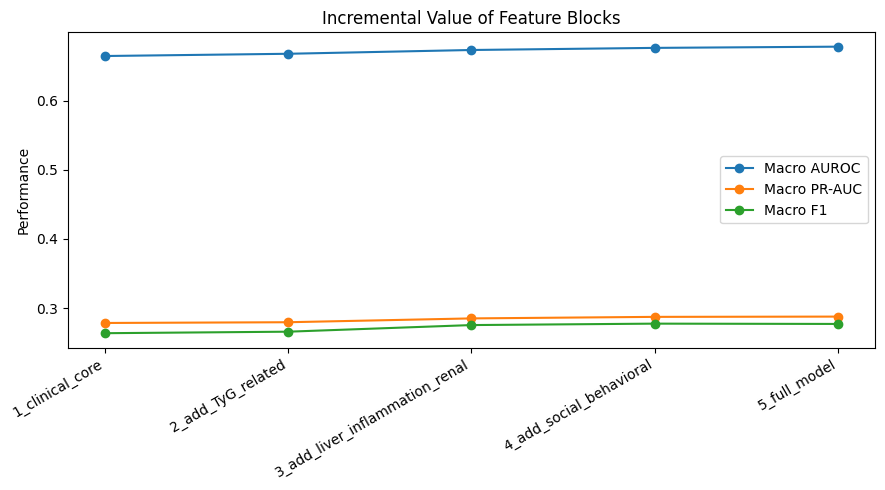

In [11]:
# ============================================================
# CELL 17 (UPDATED): INCREMENTAL VALUE ANALYSIS
# ============================================================
incremental_sets = {
    "1_clinical_core": feature_groups["clinical_core"],
    "2_add_TyG_related": feature_groups["clinical_core"] + feature_groups["tyg_related"],
    "3_add_liver_inflammation_renal": (
        feature_groups["clinical_core"] +
        feature_groups["tyg_related"] +
        feature_groups["liver_markers"] +
        feature_groups["inflammation_markers"] +
        feature_groups["renal_markers"]
    ),
    "4_add_social_behavioral": (
        feature_groups["clinical_core"] +
        feature_groups["tyg_related"] +
        feature_groups["liver_markers"] +
        feature_groups["inflammation_markers"] +
        feature_groups["renal_markers"] +
        feature_groups["social_behavioral"]
    ),
    "5_full_model": all_features
}

incremental_rows = []

for name, feats in incremental_sets.items():
    feats = [c for c in dict.fromkeys(feats) if c in df_analysis.columns]

    res = run_analysis_on_subset(
        df_analysis,
        feats,
        name,
        categorical_features
    )
    if res is not None:
        incremental_rows.append(res)

incremental_table = pd.concat(incremental_rows, ignore_index=True)
print("Incremental value results:")
display(incremental_table.round(4))

# ============================================================
# CELL 17B: PLOT INCREMENTAL VALUE
# ============================================================
plot_df = incremental_table.copy()

plt.figure(figsize=(9, 5))
plt.plot(plot_df["model"], plot_df["macro_auroc_ovr"], marker="o", label="Macro AUROC")
plt.plot(plot_df["model"], plot_df["macro_prauc_ovr"], marker="o", label="Macro PR-AUC")
plt.plot(plot_df["model"], plot_df["macro_f1"], marker="o", label="Macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Performance")
plt.title("Incremental Value of Feature Blocks")
plt.legend()
plt.tight_layout()
plt.show()

# dominance analysis

In [12]:
# ============================================================
# CELL 18 (UPDATED): DROP-ONE-BLOCK ANALYSIS
# ============================================================
drop_sets = {
    "full_model": all_features,
    "drop_HbA1c": [c for c in all_features if c != "HbA1c"],
    "drop_Cr": [c for c in all_features if c != "Cr"],
    "drop_Cys": [c for c in all_features if c != "Cys"],
    "drop_TyG_related": [c for c in all_features if c not in feature_groups["tyg_related"]],
    "drop_liver_markers": [c for c in all_features if c not in feature_groups["liver_markers"]],
    "drop_inflammation_markers": [c for c in all_features if c not in feature_groups["inflammation_markers"]],
    "drop_social_behavioral": [c for c in all_features if c not in feature_groups["social_behavioral"]],
}

drop_rows = []

for name, feats in drop_sets.items():
    feats = [c for c in feats if c in df_analysis.columns]
    res = run_analysis_on_subset(
        df_analysis,
        feats,
        name,
        categorical_features
    )
    if res is not None:
        drop_rows.append(res)

drop_table = pd.concat(drop_rows, ignore_index=True)
print("Drop-one-block results:")
display(drop_table.round(4))

full_model: fold 1 done
full_model: fold 2 done
full_model: fold 3 done
full_model: fold 4 done
full_model: fold 5 done
drop_HbA1c: fold 1 done
drop_HbA1c: fold 2 done
drop_HbA1c: fold 3 done
drop_HbA1c: fold 4 done
drop_HbA1c: fold 5 done
drop_Cr: fold 1 done
drop_Cr: fold 2 done
drop_Cr: fold 3 done
drop_Cr: fold 4 done
drop_Cr: fold 5 done
drop_Cys: fold 1 done
drop_Cys: fold 2 done
drop_Cys: fold 3 done
drop_Cys: fold 4 done
drop_Cys: fold 5 done
drop_TyG_related: fold 1 done
drop_TyG_related: fold 2 done
drop_TyG_related: fold 3 done
drop_TyG_related: fold 4 done
drop_TyG_related: fold 5 done
drop_liver_markers: fold 1 done
drop_liver_markers: fold 2 done
drop_liver_markers: fold 3 done
drop_liver_markers: fold 4 done
drop_liver_markers: fold 5 done
drop_inflammation_markers: fold 1 done
drop_inflammation_markers: fold 2 done
drop_inflammation_markers: fold 3 done
drop_inflammation_markers: fold 4 done
drop_inflammation_markers: fold 5 done
drop_social_behavioral: fold 1 done
drop

,model,macro_f1,weighted_f1,macro_precision,weighted_precision,macro_recall,weighted_recall,macro_auroc_ovr,weighted_auroc_ovr,macro_prauc_ovr,weighted_prauc_ovr,n,n_classes
0,full_model,0.2770,0.4253,0.2854,0.4973,0.3155,0.4054,0.6779,0.6571,0.2876,0.4961,89872,5
1,drop_HbA1c,0.2725,0.4292,0.2795,0.4926,0.3021,0.4068,0.6636,0.6513,0.2819,0.4916,89872,5
2,drop_Cr,0.2752,0.4235,0.2834,0.4948,0.3128,0.4032,0.6722,0.6548,0.2855,0.4939,89872,5
3,drop_Cys,0.2770,0.4235,0.2855,0.4969,0.3168,0.4041,0.6727,0.6554,0.2867,0.4947,89872,5
4,drop_TyG_related,0.2767,0.4242,0.2851,0.4964,0.3160,0.4040,0.6764,0.6562,0.2867,0.4951,89872,5
5,drop_liver_markers,0.2740,0.4205,0.2834,0.4953,0.3131,0.4002,0.6790,0.6544,0.2864,0.4945,89872,5
6,drop_inflammation_markers,0.2756,0.4187,0.2862,0.4954,0.3161,0.3988,0.6774,0.6545,0.2855,0.4934,89872,5
7,drop_social_behavioral,0.2756,0.4216,0.2842,0.4948,0.3153,0.4023,0.6747,0.6529,0.2851,0.4919,89872,5


# descriptive baseline table by trajectory

In [13]:
# ============================================================
# CELL 19 (UPDATED): BASELINE CHARACTERISTICS BY TRAJECTORY
# ============================================================
selected_continuous = [c for c in [
    "age", "BMI", "WC", "SBP", "DBP", "HbA1c", "Glucose",
    "Cr", "Cys", "TyGWHtR", "TG_HDL_ratio", "CRP", "Survival_time", "hip"
] if c in df_analysis.columns]

selected_categorical = [c for c in [
    "sex", "ethnic", "education", "employment", "income",
    "smoking", "drinking", "Regular_physical_activity", "Healthy_diet"
] if c in df_analysis.columns]

table1_rows = []

for var in selected_continuous:
    row = {"variable": var}
    for traj, g in df_analysis.groupby("trajectory"):
        x = pd.to_numeric(g[var], errors="coerce").dropna()
        if len(x) == 0:
            row[traj] = "NA"
        else:
            row[traj] = f"{x.median():.2f} [{x.quantile(0.25):.2f}, {x.quantile(0.75):.2f}]"
    table1_rows.append(row)

for var in selected_categorical:
    levels = df_analysis[var].astype(str).fillna("missing").unique()
    for lvl in sorted(levels):
        row = {"variable": f"{var} = {lvl}"}
        for traj, g in df_analysis.groupby("trajectory"):
            g2 = g[var].astype(str).fillna("missing")
            cnt = (g2 == lvl).sum()
            pct = 100 * cnt / len(g2) if len(g2) > 0 else np.nan
            row[traj] = f"{cnt} ({pct:.1f}%)"
        table1_rows.append(row)

table1 = pd.DataFrame(table1_rows)
display(table1)

,variable,A,B,C,D,F
0,age,"61.00 [54.00, 65.00]","63.00 [59.00, 67.00]","62.00 [56.00, 66.00]","63.00 [57.50, 66.00]","62.00 [57.00, 66.00]"
1,BMI,"28.09 [25.37, 31.40]","28.92 [25.88, 32.62]","29.90 [26.89, 33.63]","30.04 [27.24, 33.82]","26.63 [24.01, 29.72]"
2,WC,"95.00 [86.00, 103.00]","98.00 [89.00, 107.00]","100.00 [92.00, 109.00]","100.00 [91.50, 110.50]","91.00 [82.00, 100.00]"
3,SBP,"143.00 [130.00, 157.00]","146.00 [132.00, 159.00]","146.00 [131.00, 159.00]","147.00 [130.00, 158.00]","142.00 [129.00, 156.00]"
4,DBP,"84.00 [77.00, 91.00]","84.00 [77.00, 91.00]","84.00 [78.00, 91.00]","84.00 [77.00, 92.00]","84.00 [76.00, 90.00]"
5,HbA1c,"36.40 [33.70, 39.70]","37.80 [34.70, 42.00]","40.30 [36.10, 47.00]","41.00 [36.75, 46.75]","35.40 [33.10, 37.90]"
6,Glucose,"90.37 [83.92, 99.16]","92.23 [84.84, 103.85]","95.90 [86.75, 115.61]","94.50 [83.65, 110.49]","89.18 [83.24, 95.85]"
7,Cr,"73.00 [63.20, 83.40]","75.10 [64.70, 86.90]","76.50 [66.40, 88.50]","87.70 [72.45, 99.80]","70.70 [61.40, 81.40]"
8,Cys,"0.93 [0.84, 1.03]","0.99 [0.89, 1.11]","0.99 [0.89, 1.11]","1.08 [0.93, 1.22]","0.93 [0.84, 1.03]"
9,TyGWHtR,"4.96 [4.43, 5.53]","5.18 [4.60, 5.79]","5.41 [4.86, 6.01]","5.35 [4.96, 6.04]","4.71 [4.18, 5.24]"


# stacked trajectory probability across biomarker quintiles


HbA1c


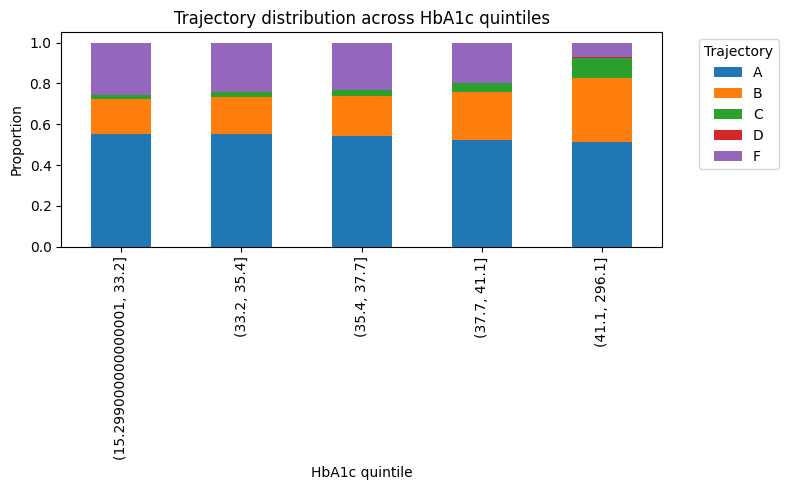

trajectory,A,B,C,D,F
quintile,,,,,
"(15.299000000000001, 33.2]",0.553,0.168,0.023,0.001,0.255
"(33.2, 35.4]",0.554,0.181,0.024,0.000,0.241
"(35.4, 37.7]",0.542,0.196,0.029,0.001,0.232
"(37.7, 41.1]",0.523,0.236,0.041,0.002,0.198
"(41.1, 296.1]",0.511,0.315,0.098,0.004,0.072



Cys


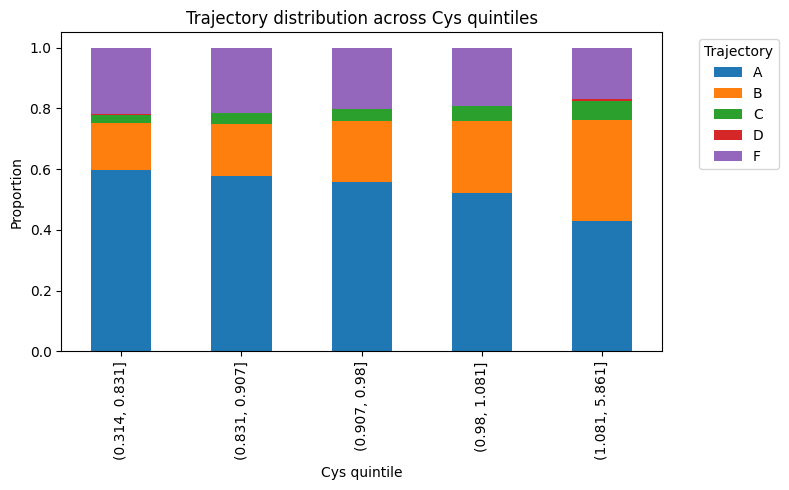

trajectory,A,B,C,D,F
quintile,,,,,
"(0.314, 0.831]",0.598,0.154,0.027,0.001,0.220
"(0.831, 0.907]",0.577,0.171,0.035,0.001,0.215
"(0.907, 0.98]",0.558,0.201,0.039,0.001,0.201
"(0.98, 1.081]",0.522,0.236,0.049,0.001,0.192
"(1.081, 5.861]",0.428,0.333,0.064,0.004,0.171



TyGWHtR


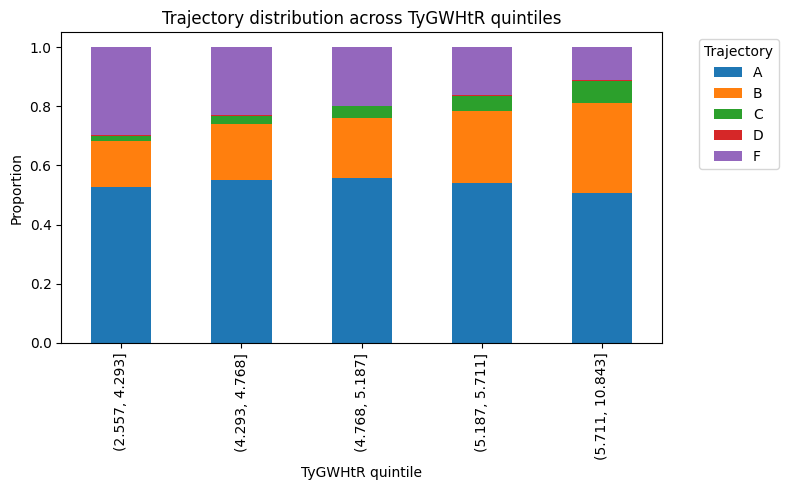

trajectory,A,B,C,D,F
quintile,,,,,
"(2.557, 4.293]",0.527,0.155,0.019,0.001,0.298
"(4.293, 4.768]",0.552,0.189,0.027,0.001,0.231
"(4.768, 5.187]",0.557,0.204,0.039,0.002,0.198
"(5.187, 5.711]",0.541,0.242,0.053,0.002,0.162
"(5.711, 10.843]",0.507,0.303,0.077,0.003,0.110


In [14]:
# ============================================================
# CELL 20 (UPDATED): STACKED EMPIRICAL TRAJECTORY DISTRIBUTIONS
# ============================================================
def stacked_probability_by_quintile(df_in, biomarker, target_col="trajectory"):
    if biomarker not in df_in.columns:
        print(f"{biomarker} not found.")
        return None

    tmp = df_in[[biomarker, target_col]].copy()
    tmp[biomarker] = pd.to_numeric(tmp[biomarker], errors="coerce")
    tmp = tmp.dropna()

    if tmp[biomarker].nunique() < 5:
        print(f"{biomarker} has too few unique values.")
        return None

    tmp["quintile"] = pd.qcut(tmp[biomarker], q=5, duplicates="drop")
    prob = pd.crosstab(tmp["quintile"], tmp[target_col], normalize="index")

    prob.plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"Trajectory distribution across {biomarker} quintiles")
    plt.ylabel("Proportion")
    plt.xlabel(f"{biomarker} quintile")
    plt.legend(title="Trajectory", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return prob

for biomarker in ["HbA1c", "Cys", "TyGWHtR"]:
    if biomarker in df_analysis.columns:
        print(f"\n{biomarker}")
        prob = stacked_probability_by_quintile(df_analysis, biomarker)
        if prob is not None:
            display(prob.round(3))

# predicted probabilities across quintiles


Predicted probabilities for HbA1c


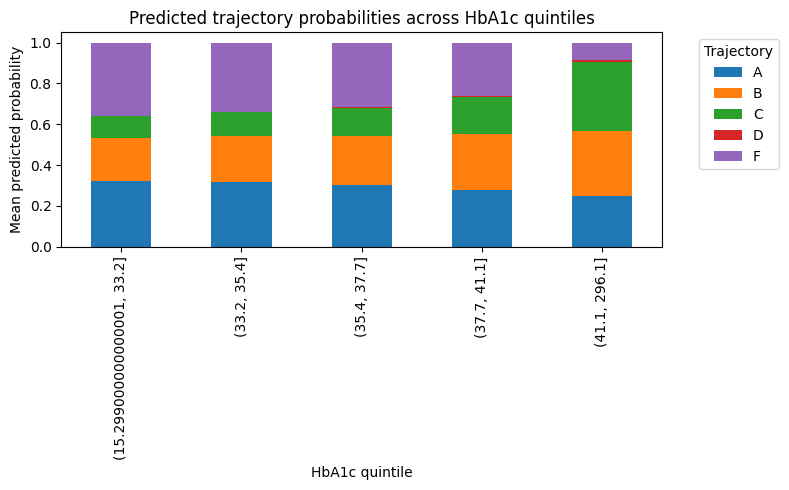

,A,B,C,D,F
quintile,,,,,
"(15.299000000000001, 33.2]",0.323,0.211,0.104,0.003,0.359
"(33.2, 35.4]",0.317,0.227,0.114,0.003,0.339
"(35.4, 37.7]",0.304,0.240,0.138,0.005,0.314
"(37.7, 41.1]",0.280,0.272,0.180,0.007,0.261
"(41.1, 296.1]",0.247,0.320,0.337,0.013,0.083



Predicted probabilities for Cys


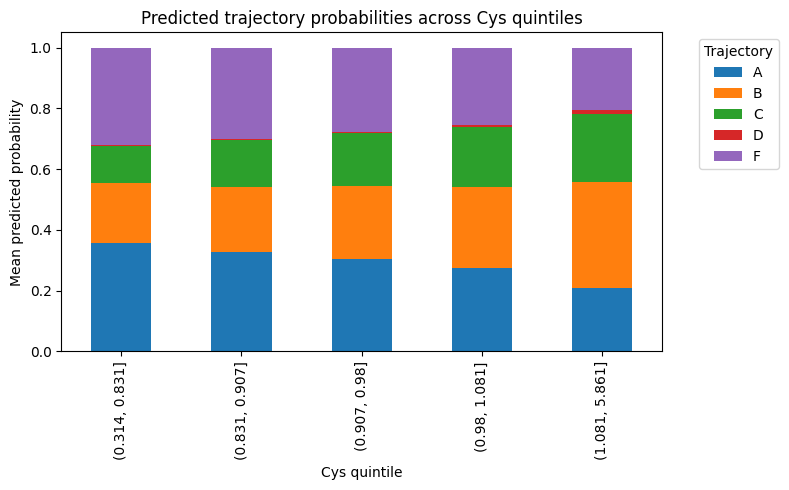

,A,B,C,D,F
quintile,,,,,
"(0.314, 0.831]",0.357,0.197,0.122,0.002,0.321
"(0.831, 0.907]",0.326,0.215,0.155,0.004,0.300
"(0.907, 0.98]",0.305,0.239,0.174,0.004,0.278
"(0.98, 1.081]",0.275,0.268,0.197,0.006,0.255
"(1.081, 5.861]",0.208,0.350,0.222,0.014,0.206



Predicted probabilities for TyGWHtR


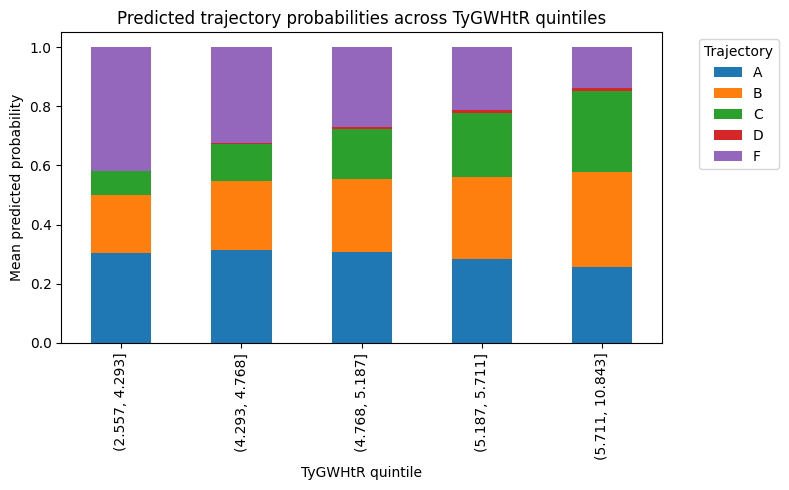

,A,B,C,D,F
quintile,,,,,
"(2.557, 4.293]",0.305,0.196,0.079,0.002,0.418
"(4.293, 4.768]",0.315,0.232,0.126,0.004,0.324
"(4.768, 5.187]",0.309,0.244,0.171,0.006,0.269
"(5.187, 5.711]",0.285,0.275,0.219,0.008,0.214
"(5.711, 10.843]",0.257,0.321,0.275,0.010,0.137


In [15]:
# ============================================================
# CELL 21 (UPDATED): MODEL-PREDICTED PROBABILITIES ACROSS QUINTILES
# ============================================================
xgb_model.fit(X_raw, y, model__sample_weight=sample_weights)

df_pred = df_analysis.copy()
pred_proba_full = xgb_model.predict_proba(X_raw)

for i, cname in enumerate(class_names):
    df_pred[f"pred_{cname}"] = pred_proba_full[:, i]

def predicted_prob_by_quintile(df_in, biomarker):
    cols = [biomarker] + [f"pred_{c}" for c in class_names]
    tmp = df_in[cols].copy()
    tmp[biomarker] = pd.to_numeric(tmp[biomarker], errors="coerce")
    tmp = tmp.dropna()

    if tmp[biomarker].nunique() < 5:
        print(f"{biomarker} has too few unique values.")
        return None

    tmp["quintile"] = pd.qcut(tmp[biomarker], q=5, duplicates="drop")
    out = tmp.groupby("quintile")[[f"pred_{c}" for c in class_names]].mean()
    out.columns = class_names

    out.plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"Predicted trajectory probabilities across {biomarker} quintiles")
    plt.ylabel("Mean predicted probability")
    plt.xlabel(f"{biomarker} quintile")
    plt.legend(title="Trajectory", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return out

for biomarker in ["HbA1c", "Cys", "TyGWHtR"]:
    if biomarker in df_pred.columns:
        print(f"\nPredicted probabilities for {biomarker}")
        out = predicted_prob_by_quintile(df_pred, biomarker)
        if out is not None:
            display(out.round(3))